# MLP
### Filip Piotrowski

### Wczytywanie bibliotek

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from matplotlib import cm
import copy
import seaborn as sns

### Przerzucenie obliczeń na GPU lub CPU

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Pracujemy na: {device}")

Pracujemy na: cuda


### Wczytywanie danych CIFAR10

In [14]:
torch.manual_seed(42)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

full_train_dataset = datasets.CIFAR10(root='data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='data', train=False, download=True, transform=transform)

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Rozmiar zbioru treningowego: {len(train_dataset)}")
print(f"Rozmiar zbioru walidacyjnego: {len(val_dataset)}")
print(f"Rozmiar zbioru testowego: {len(test_dataset)}")

c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Rozmiar zbioru treningowego: 40000
Rozmiar zbioru walidacyjnego: 10000
Rozmiar zbioru testowego: 10000


#### Zbiór CIFAR-10 to standardowy benchmark w dziedzinie rozpoznawania obrazów, składający się z 60 000 kolorowych obrazów RGB o niskiej rozdzielczości 32x32 piksele. Dane są podzielone na 10 rozłącznych klas (m.in. samolot, kot, pies, statek), przy czym zbiór jest idealnie zrównoważony – każda kategoria zawiera dokładnie 6000 próbek.

### Przykładowe obrazy

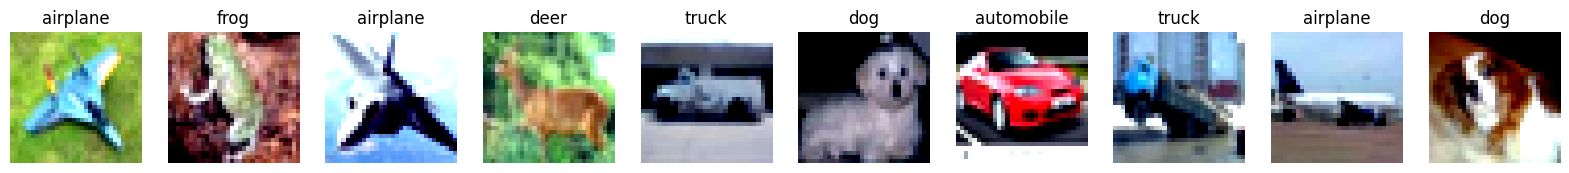

In [4]:
class_names = full_train_dataset.classes

examples = enumerate(train_loader)
batch_idx, (example_data, example_targets) = next(examples)

plt.figure(figsize=(20, 5))
for i in range(10):
    plt.subplot(1, 10, i+1)
    
    # Naprawa obrazu (permute + odwrócenie normalizacji)
    img = example_data[i].permute(1, 2, 0).numpy()
    img = img * 0.5 + 0.5 
    img = np.clip(img, 0, 1)
    
    plt.imshow(img)
    
    # Użycie etykiety tekstowej!
    label_idx = example_targets[i].item()
    plt.title(class_names[label_idx]) # Tutaj zamieniamy np. 3 na 'cat'
    
    plt.axis('off')
plt.show()

### Tworzenie Modelu MLP (Multilayer Perceptron)

In [5]:
class MLP(nn.Module):
    def __init__(self, input_size=3072, hidden_neurons=256, num_classes=10, dropout_p=0.0):
        super().__init__()
        
        # Tworzymy sieć, gdzie druga warstwa ma np. połowę neuronów pierwszej
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_size, hidden_neurons),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),
            nn.Linear(hidden_neurons, hidden_neurons // 2), 
            nn.ReLU(),
            nn.Dropout(p=dropout_p),
            nn.Linear(hidden_neurons // 2, num_classes)
        )

    def forward(self, x):
        return self.net(x)

Funkcja do rozpoczynania eksperymentu

In [11]:
def run_experiment(hidden_neurons, dropout_p, train_loader, val_loader, epochs=30, patience=3, learning_rate=0.001):
    
    # Inicjalizacja modelu
    model = MLP(hidden_neurons=hidden_neurons, dropout_p=dropout_p).to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()
    
    history = {'train': [], 'val': []}
    best_v_loss = float('inf')
    previous_v_loss = float('inf')
    best_model_wts = None 
    patience_counter = 0
    class_names = full_train_dataset.classes

    for epoch in range(epochs):
        # TRENING
        model.train()
        t_loss = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()
            t_loss += loss.item()
            
        # WALIDACJA
        model.eval()
        v_loss = 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                v_loss += criterion(model(x), y).item()
        
        avg_train_loss = t_loss / len(train_loader)
        avg_val_loss = v_loss / len(val_loader)
        
        history['train'].append(avg_train_loss)
        history['val'].append(avg_val_loss)
        
        # LOGIKA EARLY STOPPING I ZAPISYWANIA WAG
        if avg_val_loss > previous_v_loss:
        # Błąd wzrósł w stosunku do poprzedniej epoki - model zaczyna się psuć
            patience_counter += 1
            print(f"Błąd walidacji wzrósł ({previous_v_loss:.4f} -> {avg_val_loss:.4f}). Spadek z rzędu: {patience_counter}/{patience}")
        else:
            # Błąd spadł lub jest taki sam - resetujemy licznik
            patience_counter = 0
            # Nadal warto zapisywać najlepsze wagi globalnie, żeby na końcu zwrócić najlepszy model
            if avg_val_loss < best_v_loss:
                best_v_loss = avg_val_loss
                best_model_wts = copy.deepcopy(model.state_dict())

        # Aktualizujemy błąd poprzedni na koniec epoki
        previous_v_loss = avg_val_loss
            
        if patience_counter >= patience:
            print(f"[Early Stopping] Epoka {epoch+1}: Val Loss: {avg_val_loss:.4f}")
            break

    # EWALUACJA NAJLEPSZEGO MODELU
    # Przywracamy najlepsze wagi przed generowaniem raportów
    if best_model_wts is not None:
        model.load_state_dict(best_model_wts)
    
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for x, y in val_loader:
            outputs = model(x.to(device))
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.numpy())
            
    # Obliczanie metryk końcowych
    acc = accuracy_score(all_labels, all_preds)
    cm = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, output_dict=False, target_names=class_names)

    # Przykłady źle sklasyfikowanych obrazów
    dataiter = iter(test_loader)
    images, labels = next(dataiter)

    # 3. Przeniesienie na GPU do predykcji
    images_gpu = images.to(device)
    with torch.no_grad():
        outputs = model(images_gpu)
        _, preds = torch.max(outputs, 1)

    # 4. Przeniesienie predykcji z powrotem na CPU do wizualizacji
    preds = preds.cpu() 

    fig = plt.figure(figsize=(15, 10))

    for idx in np.arange(10):
        ax = fig.add_subplot(2, 5, idx + 1, xticks=[], yticks=[])

        # 5. Konwersja na NumPy (musi być .cpu())
        img = images[idx].cpu().permute(1, 2, 0).numpy()

        # Odwrócenie normalizacji
        img = img * 0.5 + 0.5
        img = np.clip(img, 0, 1)

        plt.imshow(img)

    # Logika kolorów
        is_correct = preds[idx].item() == labels[idx].item()
        color = "green" if is_correct else "red"

    # Wyświetlanie nazw zamiast numerków (jeśli masz class_names)
        ax.set_title(f"Pred: {preds[idx].item()}\n(True: {labels[idx].item()})", color=color)

    plt.tight_layout()
    plt.show()
            
    return history, acc, cm, report, best_v_loss

Funkcja wypisująca accuracy, lost value, raport i confusion matrix dla najlepszego modelu w danej grupie testowej

In [7]:
def wykresy(acc, cm, report, size, best_v_loss):
    print("Dla najlepszego modelu:")
    print(f"Accuracy: {acc}")
    print(f"Loss value {best_v_loss:.5f}")
    print("Raport:")
    print(report)
    classes = full_train_dataset.classes 

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes)

    plt.title(f'Macierz Pomyłek - {size}') # size to zmienna z pętli
    plt.ylabel('Klasa Prawdziwa')
    plt.xlabel('Klasa Przewidziana')
    plt.show()

## Eksperymenty

### Eksperyment z ilością neuronów

ROZPOCZĘCIE EKSPERYMENTU 1: Liczba neuronów
-> Trenowanie dla warstwy o rozmiarze: 64
Błąd walidacji wzrósł (1.4419 -> 1.4575). Spadek z rzędu: 1/3
Błąd walidacji wzrósł (1.4422 -> 1.4452). Spadek z rzędu: 1/3
Błąd walidacji wzrósł (1.4452 -> 1.4564). Spadek z rzędu: 2/3
Błąd walidacji wzrósł (1.4564 -> 1.4659). Spadek z rzędu: 3/3
[Early Stopping] Epoka 11: Val Loss: 1.4659


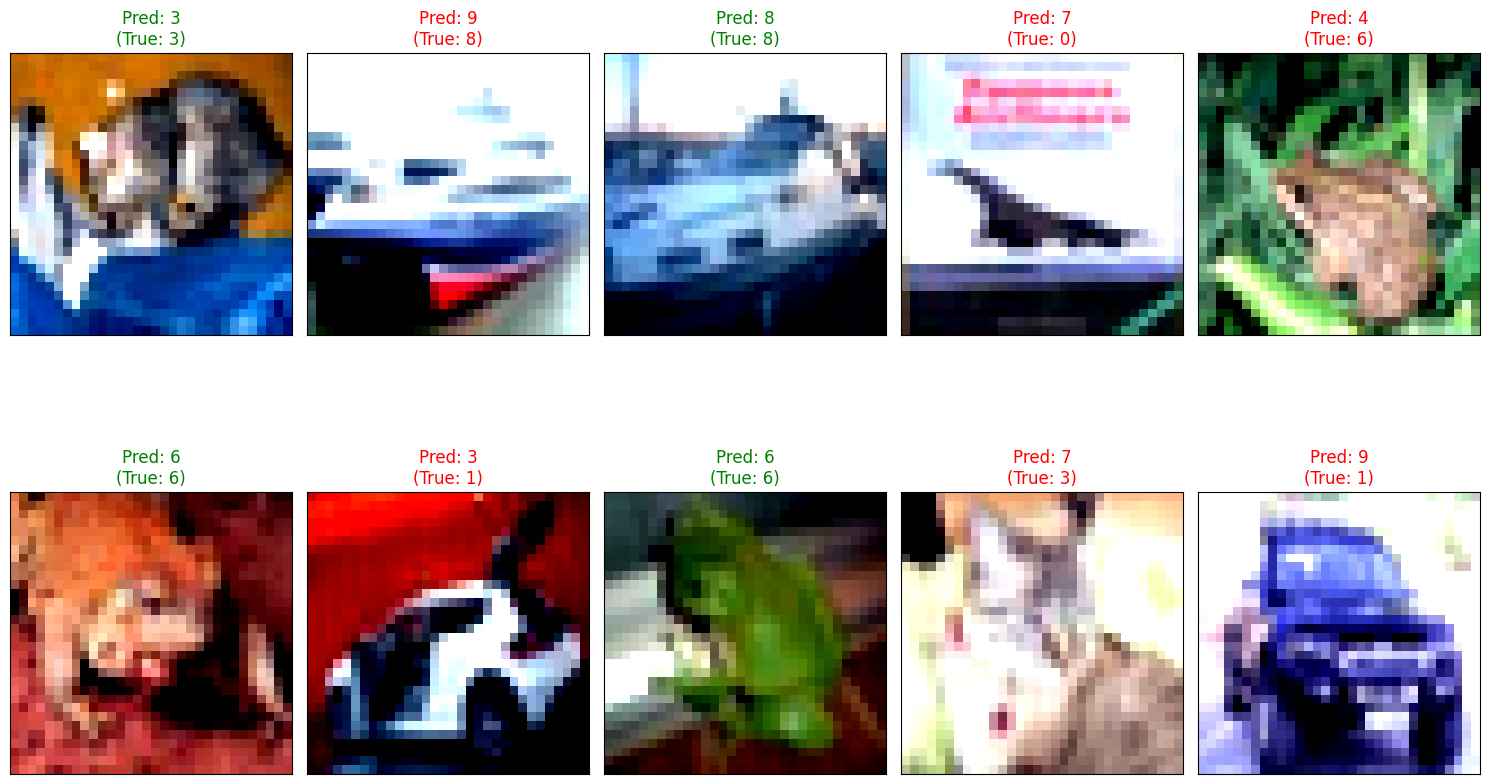

Dla najlepszego modelu:
Accuracy: 0.5019
Loss value 1.44195
Raport:
              precision    recall  f1-score   support

    airplane       0.55      0.60      0.57       973
  automobile       0.62      0.54      0.58      1010
        bird       0.36      0.43      0.39      1006
         cat       0.38      0.23      0.28       967
        deer       0.45      0.43      0.44       963
         dog       0.40      0.45      0.42      1024
        frog       0.57      0.54      0.56      1025
       horse       0.56      0.57      0.57      1035
        ship       0.62      0.64      0.63       998
       truck       0.50      0.58      0.54       999

    accuracy                           0.50     10000
   macro avg       0.50      0.50      0.50     10000
weighted avg       0.50      0.50      0.50     10000



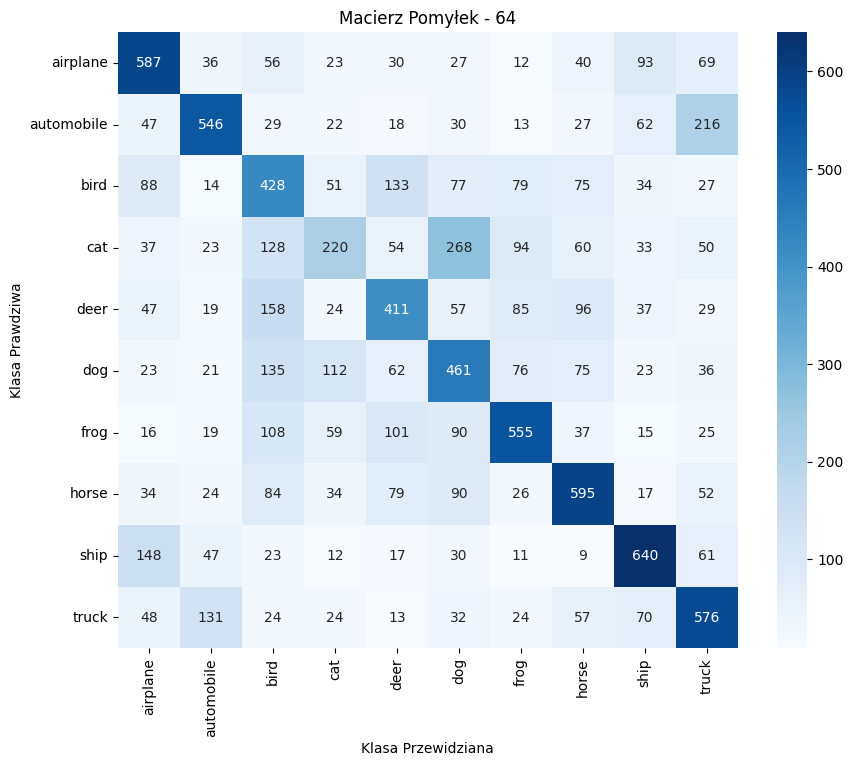

-> Trenowanie dla warstwy o rozmiarze: 128
Błąd walidacji wzrósł (1.4279 -> 1.4339). Spadek z rzędu: 1/3
Błąd walidacji wzrósł (1.4339 -> 1.4417). Spadek z rzędu: 2/3
Błąd walidacji wzrósł (1.4322 -> 1.4458). Spadek z rzędu: 1/3
Błąd walidacji wzrósł (1.4458 -> 1.4635). Spadek z rzędu: 2/3
Błąd walidacji wzrósł (1.4635 -> 1.5042). Spadek z rzędu: 3/3
[Early Stopping] Epoka 11: Val Loss: 1.5042


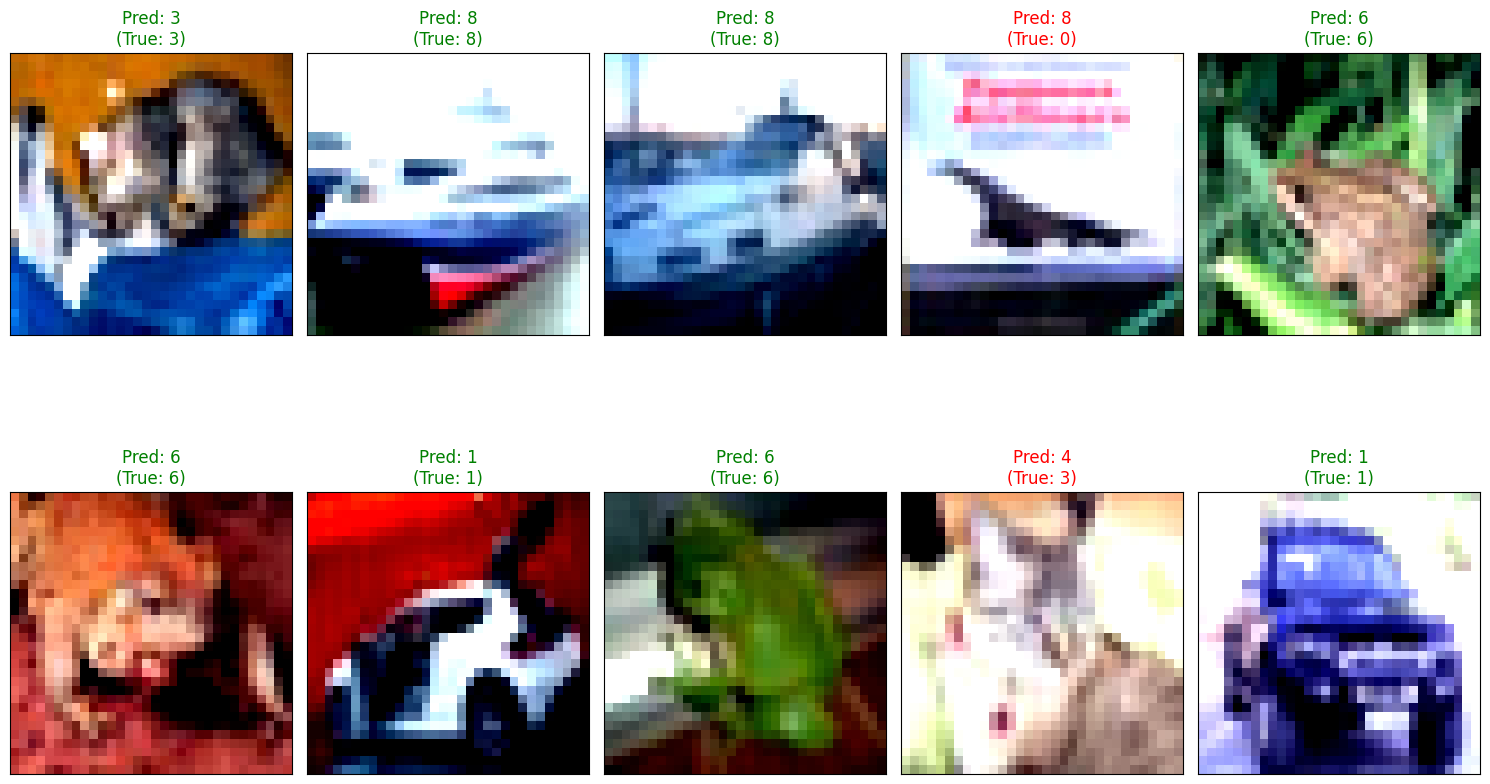

Dla najlepszego modelu:
Accuracy: 0.5025
Loss value 1.42787
Raport:
              precision    recall  f1-score   support

    airplane       0.61      0.53      0.57       973
  automobile       0.57      0.67      0.62      1010
        bird       0.45      0.29      0.35      1006
         cat       0.34      0.30      0.32       967
        deer       0.36      0.53      0.43       963
         dog       0.45      0.35      0.39      1024
        frog       0.51      0.64      0.56      1025
       horse       0.60      0.54      0.57      1035
        ship       0.57      0.71      0.63       998
       truck       0.57      0.47      0.51       999

    accuracy                           0.50     10000
   macro avg       0.50      0.50      0.50     10000
weighted avg       0.50      0.50      0.50     10000



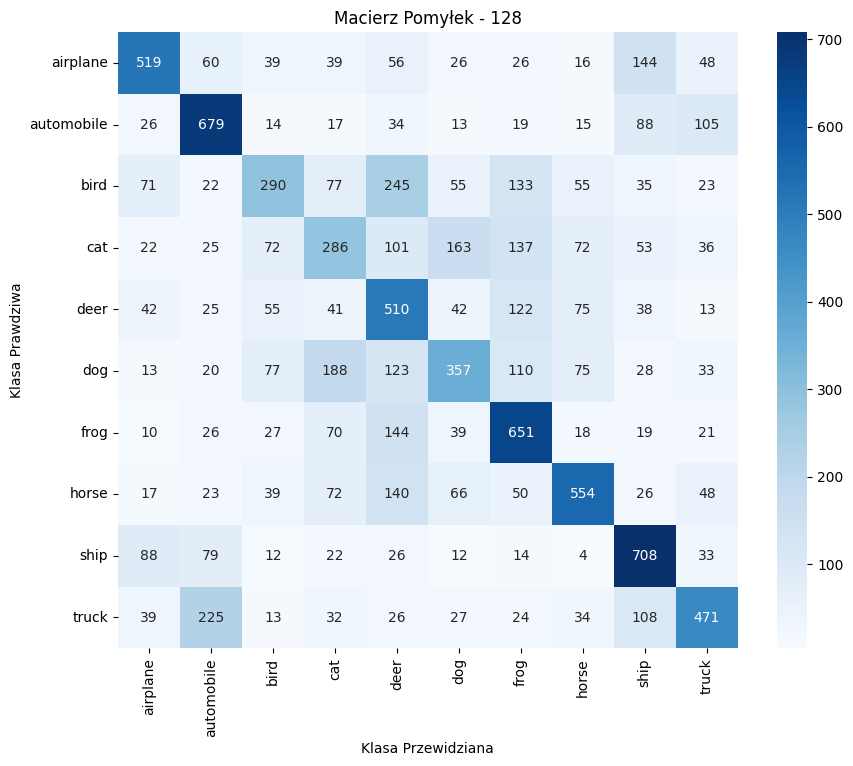

-> Trenowanie dla warstwy o rozmiarze: 256
Błąd walidacji wzrósł (1.4146 -> 1.4189). Spadek z rzędu: 1/3
Błąd walidacji wzrósł (1.4189 -> 1.4708). Spadek z rzędu: 2/3
Błąd walidacji wzrósł (1.4581 -> 1.4968). Spadek z rzędu: 1/3
Błąd walidacji wzrósł (1.4968 -> 1.4978). Spadek z rzędu: 2/3
Błąd walidacji wzrósł (1.4978 -> 1.5553). Spadek z rzędu: 3/3
[Early Stopping] Epoka 10: Val Loss: 1.5553


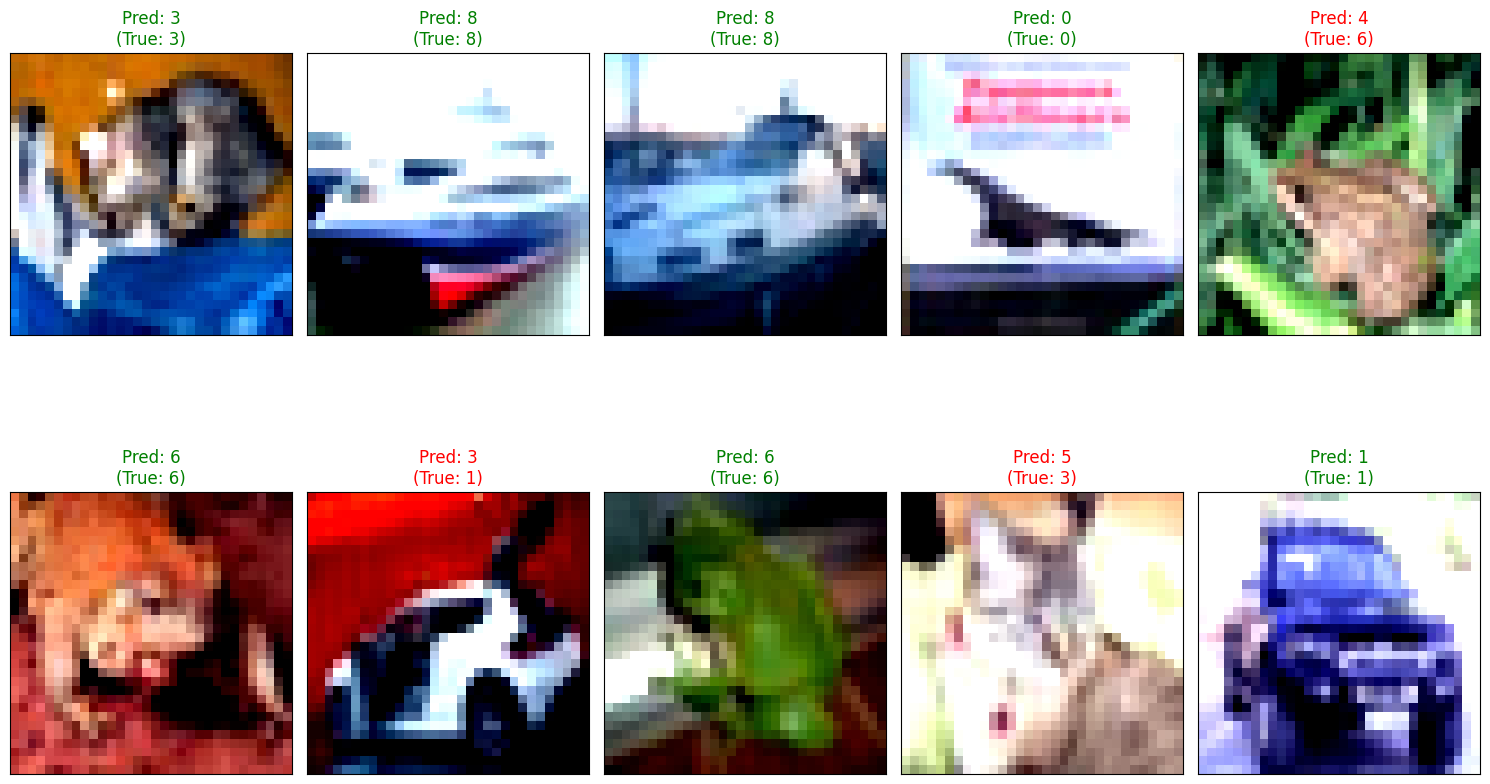

Dla najlepszego modelu:
Accuracy: 0.5071
Loss value 1.41457
Raport:
              precision    recall  f1-score   support

    airplane       0.55      0.58      0.56       973
  automobile       0.65      0.58      0.61      1010
        bird       0.43      0.33      0.37      1006
         cat       0.32      0.41      0.36       967
        deer       0.43      0.48      0.45       963
         dog       0.50      0.22      0.31      1024
        frog       0.49      0.64      0.55      1025
       horse       0.62      0.54      0.58      1035
        ship       0.58      0.72      0.64       998
       truck       0.55      0.58      0.56       999

    accuracy                           0.51     10000
   macro avg       0.51      0.51      0.50     10000
weighted avg       0.51      0.51      0.50     10000



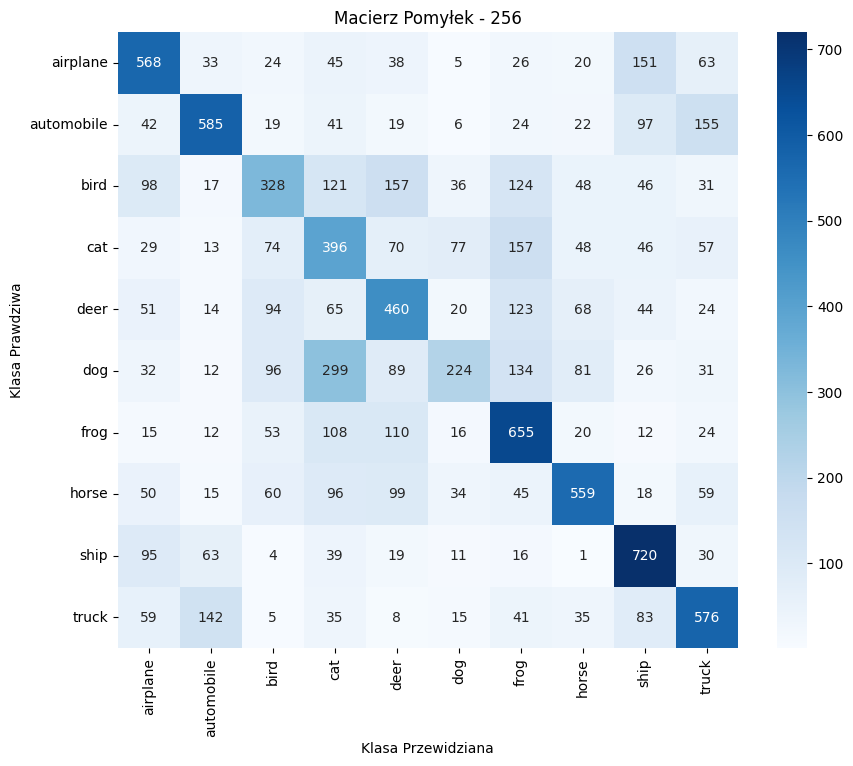

-> Trenowanie dla warstwy o rozmiarze: 512
Błąd walidacji wzrósł (1.4652 -> 1.4711). Spadek z rzędu: 1/3
Błąd walidacji wzrósł (1.3985 -> 1.4489). Spadek z rzędu: 1/3
Błąd walidacji wzrósł (1.4489 -> 1.4855). Spadek z rzędu: 2/3
Błąd walidacji wzrósł (1.4656 -> 1.5377). Spadek z rzędu: 1/3
Błąd walidacji wzrósł (1.5377 -> 1.5741). Spadek z rzędu: 2/3
Błąd walidacji wzrósł (1.5741 -> 1.6341). Spadek z rzędu: 3/3
[Early Stopping] Epoka 11: Val Loss: 1.6341


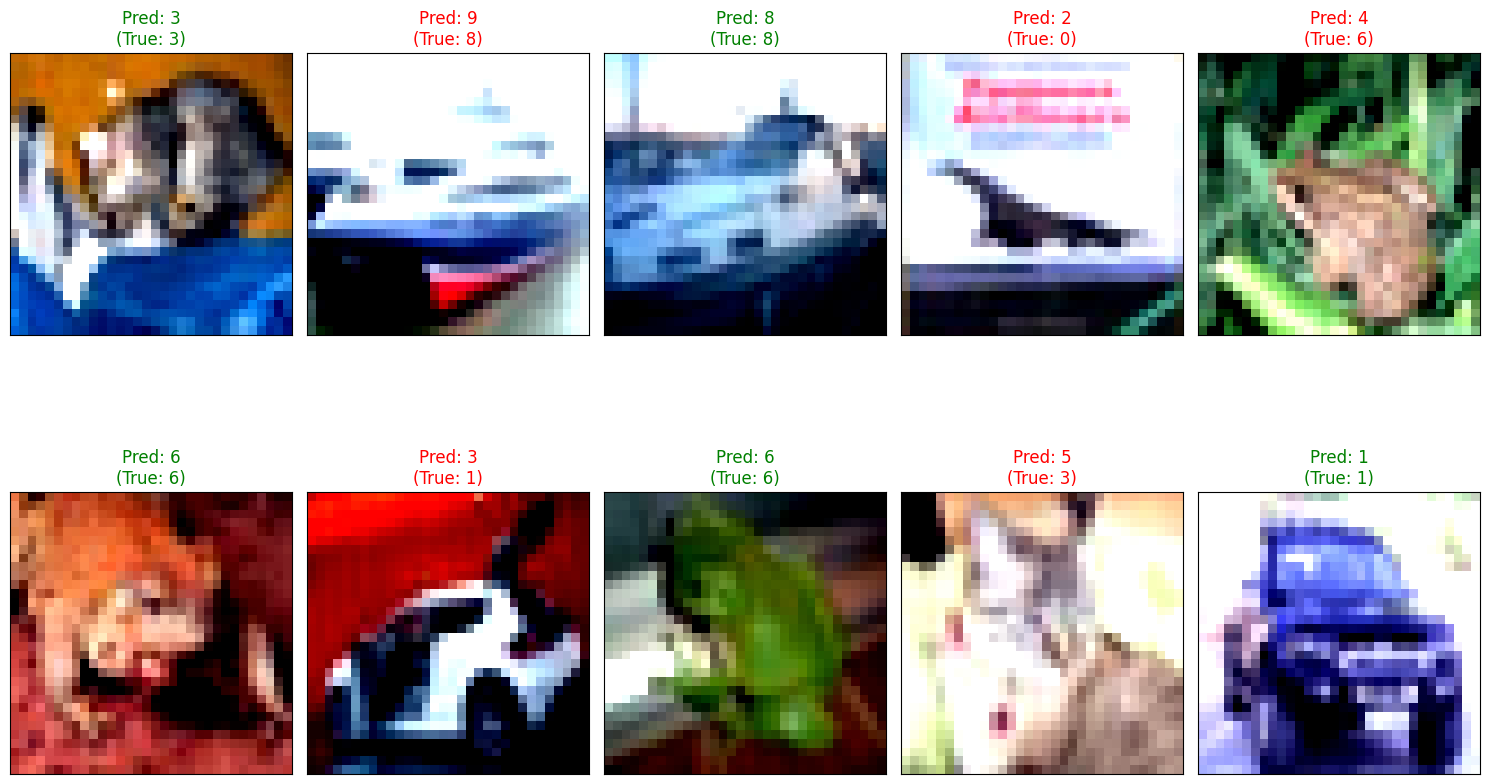

Dla najlepszego modelu:
Accuracy: 0.5186
Loss value 1.39850
Raport:
              precision    recall  f1-score   support

    airplane       0.62      0.51      0.56       973
  automobile       0.63      0.67      0.65      1010
        bird       0.41      0.39      0.40      1006
         cat       0.32      0.35      0.34       967
        deer       0.45      0.46      0.45       963
         dog       0.42      0.39      0.40      1024
        frog       0.56      0.57      0.57      1025
       horse       0.65      0.56      0.60      1035
        ship       0.57      0.72      0.64       998
       truck       0.56      0.56      0.56       999

    accuracy                           0.52     10000
   macro avg       0.52      0.52      0.52     10000
weighted avg       0.52      0.52      0.52     10000



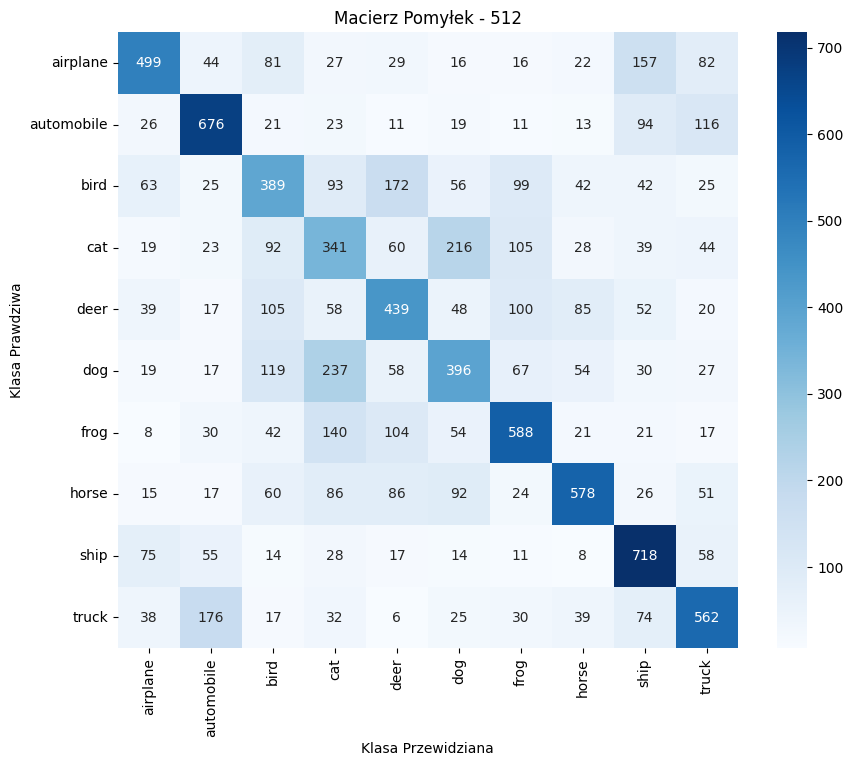

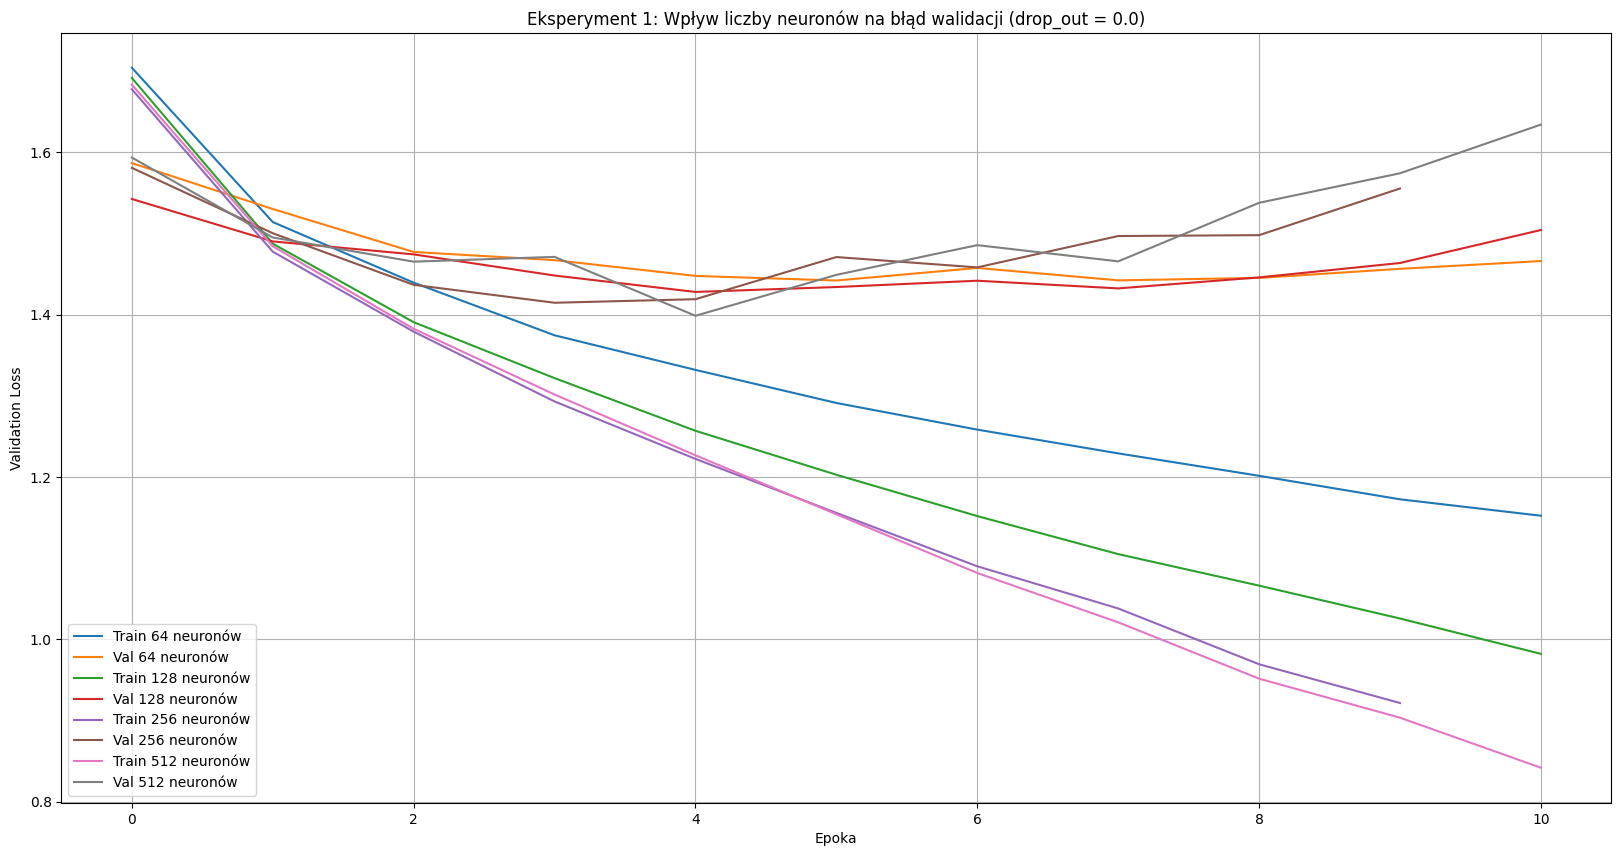

In [13]:
hidden_sizes_to_test = [64, 128, 256, 512]
results_neurons = {}

print("ROZPOCZĘCIE EKSPERYMENTU 1: Liczba neuronów")
for size in hidden_sizes_to_test:
    print(f"-> Trenowanie dla warstwy o rozmiarze: {size}")
    history, acc, cm, report, best_v_loss = run_experiment(hidden_neurons=size, dropout_p=0.0, train_loader=train_loader, val_loader=val_loader)
    results_neurons[size] = history
    wykresy(acc, cm, report, size, best_v_loss)
    

# Rysowanie wykresu
plt.figure(figsize=(20, 10))
for size, history in results_neurons.items():
    plt.plot(history['train'], label=f'Train {size} neuronów')
    plt.plot(history['val'], label=f'Val {size} neuronów')

plt.title('Eksperyment 1: Wpływ liczby neuronów na błąd walidacji (drop_out = 0.0)')
plt.xlabel('Epoka')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

##### Zwiększenie liczby neuronów powyżej 128 przyspiesza overfitting i podnosi błąd walidacji. Model z 512 neuronami (linia szara) przeucza się najszybciej – już po 4. epoce błąd walidacyjny gwałtownie rośnie, co oznacza utratę zdolności do generalizacji. Sieć z 64 neuronami, mimo stabilności, generuje najwyższy błąd (Underfitting), co świadczy o niewystarczającej pojemności informacyjnej. Optymalny balans między tempem nauki a błędem walidacji wykazują modele 128 i 256, przy czym model 128 (linia czerwona) osiąga najniższy i najstabilniejszy błąd końcowy. Wszystkie warianty bez dodatkowej regularyzacji tracą efektywność po około 5 epokach.

### Eksperyment z wartością dropout


ROZPOCZĘCIE EKSPERYMENTU 2: Dropout
-> Trenowanie z dropoutem: 0.0
Błąd walidacji wzrósł (1.4126 -> 1.4570). Spadek z rzędu: 1/3
Błąd walidacji wzrósł (1.4392 -> 1.4669). Spadek z rzędu: 1/3
Błąd walidacji wzrósł (1.4544 -> 1.4755). Spadek z rzędu: 1/3
Błąd walidacji wzrósł (1.4755 -> 1.5299). Spadek z rzędu: 2/3
Błąd walidacji wzrósł (1.5299 -> 1.5587). Spadek z rzędu: 3/3
[Early Stopping] Epoka 11: Val Loss: 1.5587


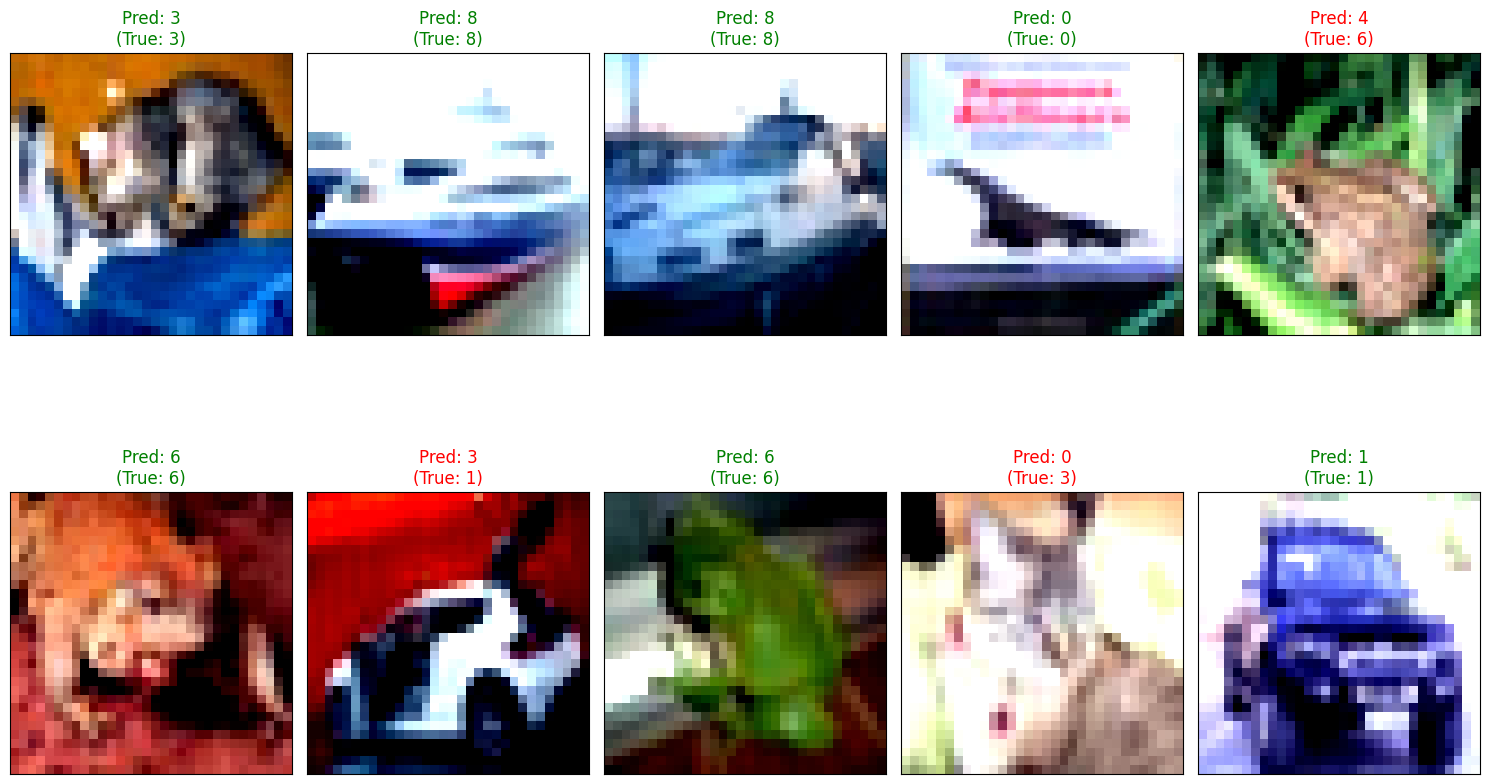

Dla najlepszego modelu:
Accuracy: 0.5095
Loss value 1.41260
Raport:
              precision    recall  f1-score   support

    airplane       0.55      0.58      0.57       973
  automobile       0.62      0.60      0.61      1010
        bird       0.42      0.41      0.41      1006
         cat       0.32      0.38      0.35       967
        deer       0.48      0.37      0.42       963
         dog       0.45      0.34      0.39      1024
        frog       0.56      0.53      0.55      1025
       horse       0.54      0.63      0.58      1035
        ship       0.57      0.73      0.64       998
       truck       0.57      0.53      0.55       999

    accuracy                           0.51     10000
   macro avg       0.51      0.51      0.51     10000
weighted avg       0.51      0.51      0.51     10000



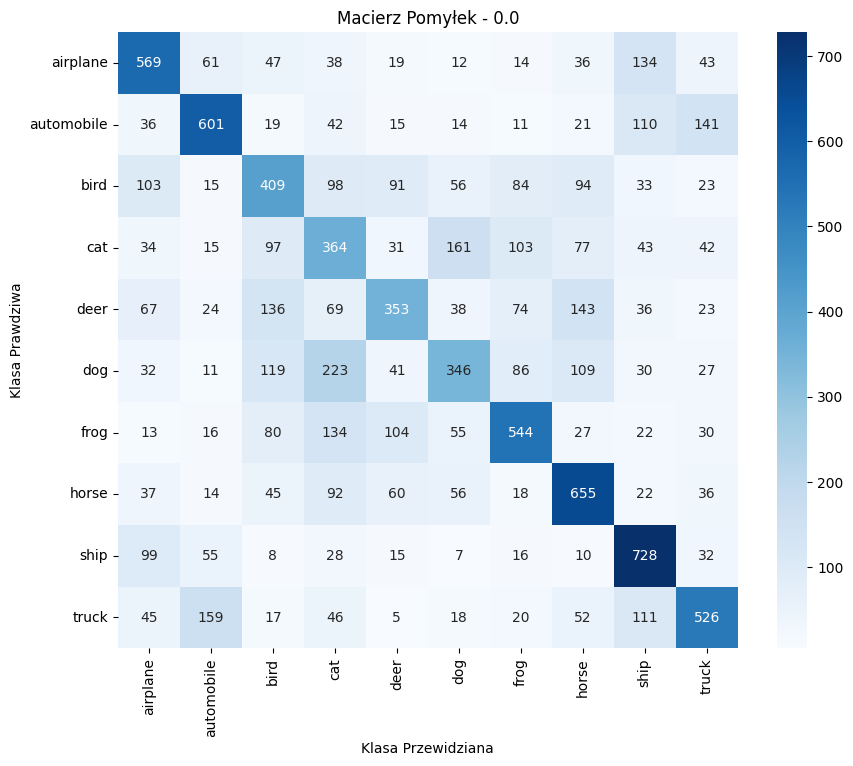

-> Trenowanie z dropoutem: 0.3
Błąd walidacji wzrósł (1.4072 -> 1.4137). Spadek z rzędu: 1/3
Błąd walidacji wzrósł (1.3867 -> 1.3984). Spadek z rzędu: 1/3
Błąd walidacji wzrósł (1.3984 -> 1.4070). Spadek z rzędu: 2/3
Błąd walidacji wzrósł (1.3841 -> 1.3900). Spadek z rzędu: 1/3
Błąd walidacji wzrósł (1.3900 -> 1.4026). Spadek z rzędu: 2/3
Błąd walidacji wzrósł (1.3844 -> 1.3881). Spadek z rzędu: 1/3
Błąd walidacji wzrósł (1.3881 -> 1.4031). Spadek z rzędu: 2/3
Błąd walidacji wzrósł (1.3762 -> 1.3814). Spadek z rzędu: 1/3


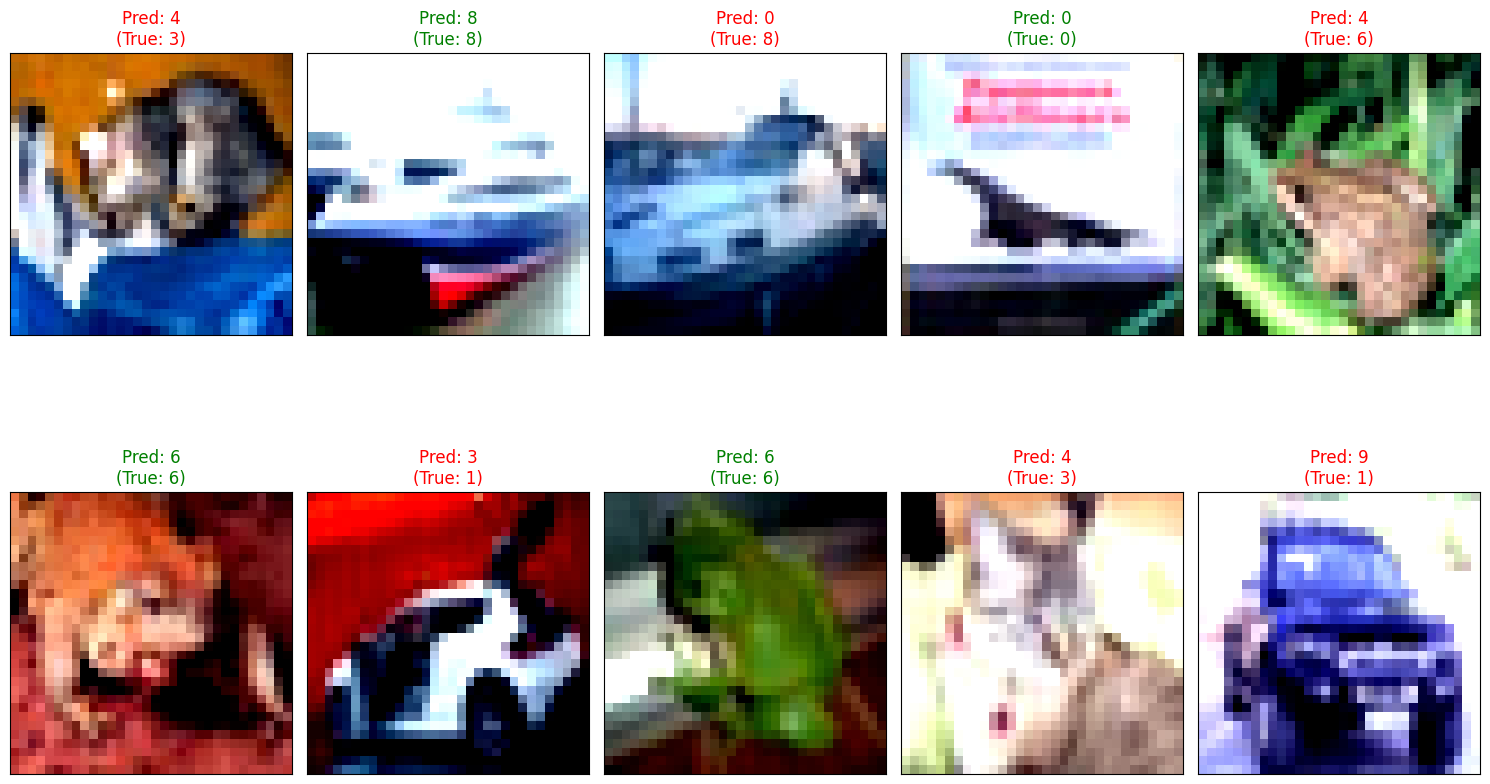

Dla najlepszego modelu:
Accuracy: 0.5218
Loss value 1.37620
Raport:
              precision    recall  f1-score   support

    airplane       0.57      0.60      0.59       973
  automobile       0.67      0.61      0.64      1010
        bird       0.40      0.41      0.40      1006
         cat       0.32      0.41      0.36       967
        deer       0.37      0.49      0.42       963
         dog       0.47      0.35      0.41      1024
        frog       0.53      0.63      0.58      1025
       horse       0.69      0.55      0.61      1035
        ship       0.71      0.60      0.65       998
       truck       0.63      0.56      0.59       999

    accuracy                           0.52     10000
   macro avg       0.54      0.52      0.53     10000
weighted avg       0.54      0.52      0.53     10000



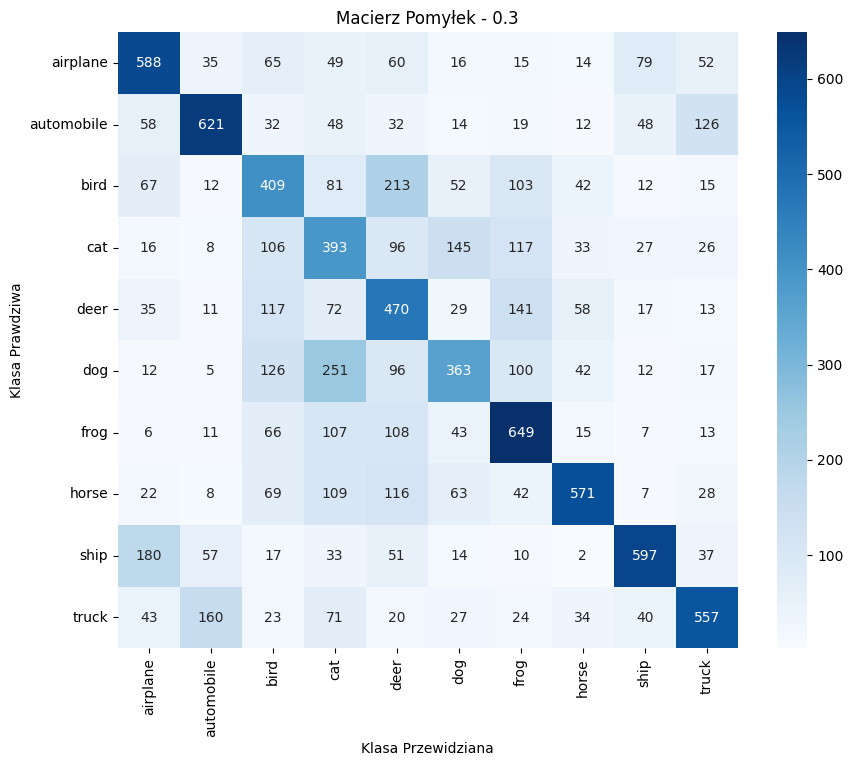

-> Trenowanie z dropoutem: 0.5
Błąd walidacji wzrósł (1.6664 -> 1.6677). Spadek z rzędu: 1/3
Błąd walidacji wzrósł (1.6389 -> 1.6430). Spadek z rzędu: 1/3
Błąd walidacji wzrósł (1.5701 -> 1.5931). Spadek z rzędu: 1/3
Błąd walidacji wzrósł (1.5338 -> 1.5508). Spadek z rzędu: 1/3
Błąd walidacji wzrósł (1.5257 -> 1.5355). Spadek z rzędu: 1/3
Błąd walidacji wzrósł (1.5235 -> 1.5345). Spadek z rzędu: 1/3
Błąd walidacji wzrósł (1.5249 -> 1.5360). Spadek z rzędu: 1/3
Błąd walidacji wzrósł (1.5172 -> 1.5344). Spadek z rzędu: 1/3
Błąd walidacji wzrósł (1.5078 -> 1.5211). Spadek z rzędu: 1/3


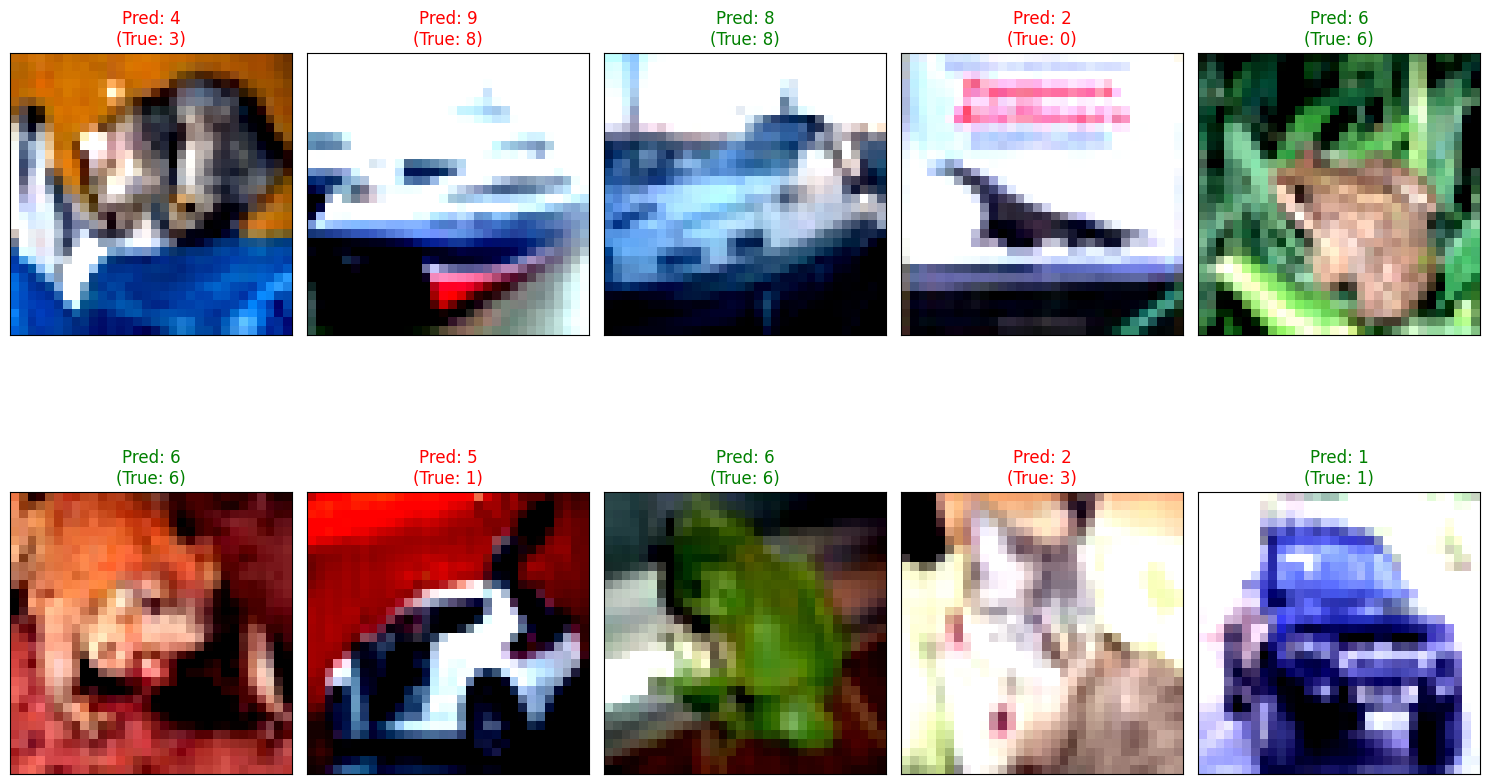

Dla najlepszego modelu:
Accuracy: 0.4725
Loss value 1.50776
Raport:
              precision    recall  f1-score   support

    airplane       0.58      0.53      0.55       973
  automobile       0.65      0.55      0.60      1010
        bird       0.34      0.34      0.34      1006
         cat       0.24      0.25      0.24       967
        deer       0.36      0.42      0.39       963
         dog       0.34      0.41      0.37      1024
        frog       0.45      0.61      0.52      1025
       horse       0.70      0.48      0.57      1035
        ship       0.69      0.58      0.63       998
       truck       0.57      0.55      0.56       999

    accuracy                           0.47     10000
   macro avg       0.49      0.47      0.48     10000
weighted avg       0.49      0.47      0.48     10000



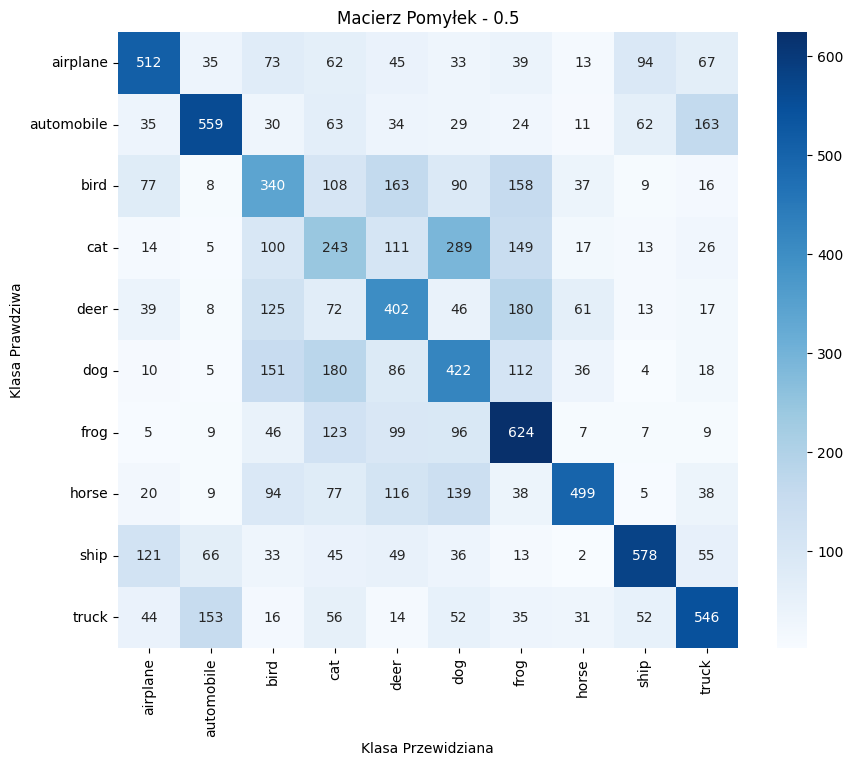

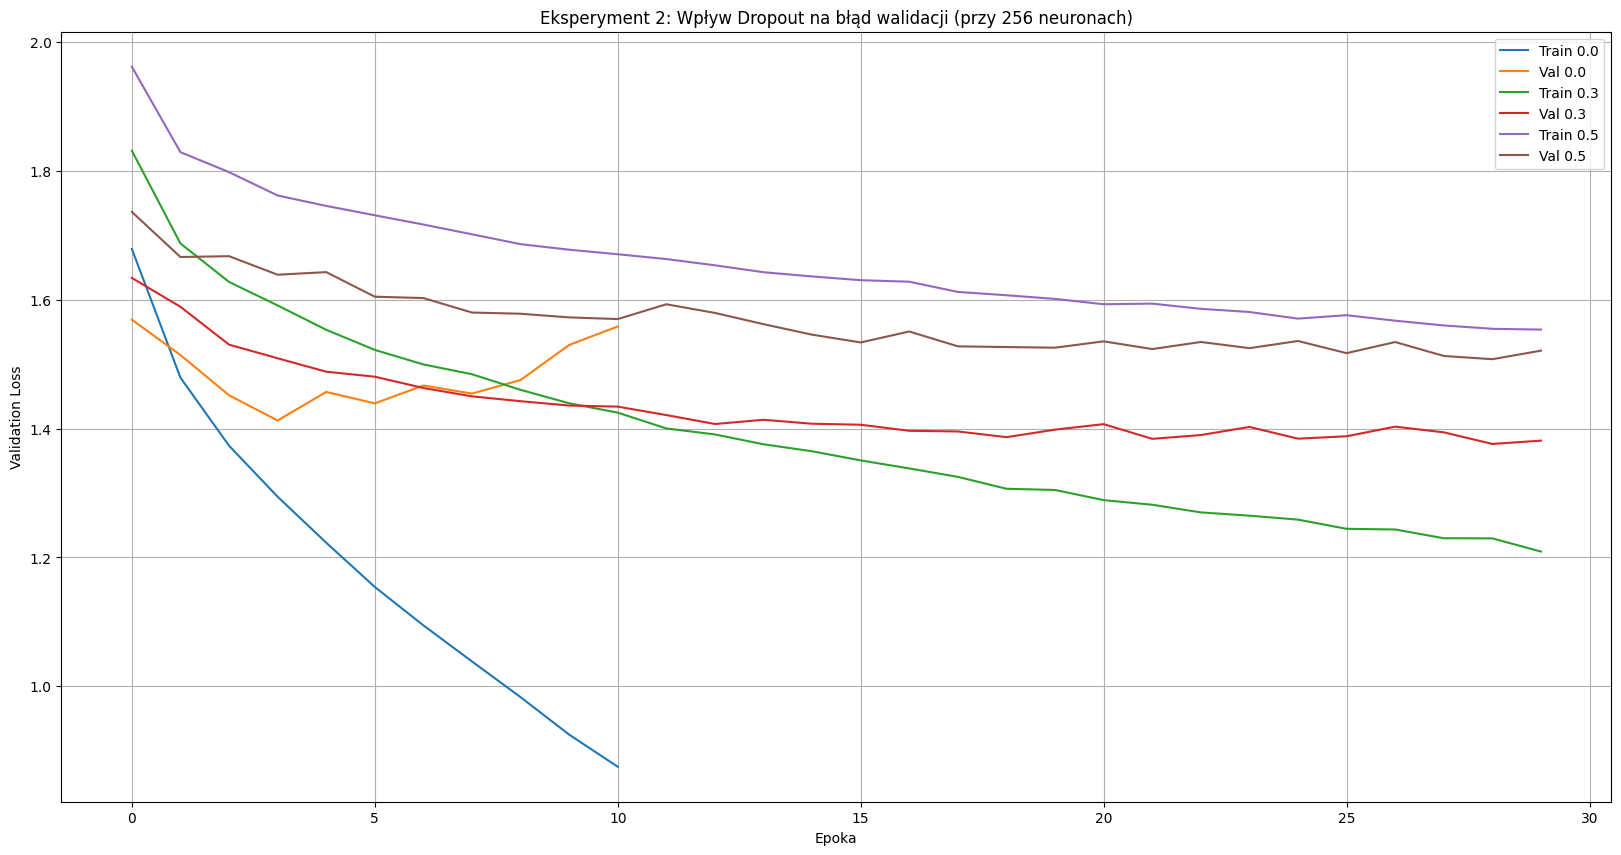

In [15]:
dropout_rates_to_test = [0.0, 0.3, 0.5]
results_dropout = {}

print("\nROZPOCZĘCIE EKSPERYMENTU 2: Dropout")
for drop_p in dropout_rates_to_test:
    print(f"-> Trenowanie z dropoutem: {drop_p}")
    # Używamy 256 neuronów jako stałej bazy
    history, acc, cm, report, best_v_loss = run_experiment(hidden_neurons=256, dropout_p=drop_p, train_loader=train_loader, val_loader=val_loader)
    results_dropout[drop_p] = history
    wykresy(acc, cm, report, drop_p, best_v_loss)

# Rysowanie wykresu
plt.figure(figsize=(20, 10))
for drop_p, history in results_dropout.items():
    plt.plot(history['train'], label=f'Train {drop_p}')
    plt.plot(history['val'], label=f'Val {drop_p}')

plt.title('Eksperyment 2: Wpływ Dropout na błąd walidacji (przy 256 neuronach)')
plt.xlabel('Epoka')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(True)

##### Eksperyment wykazał, że warstwa Dropout jest niezbędna do stabilizacji nauki na zbiorze CIFAR-10. Model bazowy (0.0) ulegał gwałtownemu overfittingowi już po 3. epoce, tracąc zdolność generalizacji. Wprowadzenie Dropoutu skutecznie wyhamowało ten proces, zmuszając sieć do uczenia się istotnych cech zamiast zapamiętywania szumu.

##### Za optymalną wartość uznano 0.3, co pozwoliło osiągnąć najniższy błąd walidacyjny (ok. 1.38). Dropout 0.5 okazał się zbyt restrykcyjny, prowadząc do underfittingu (niedouczenia) i uniemożliwiając sieci skuteczne dopasowanie się do wzorców. Regularyzacja spowalnia naukę, ale jest kluczowa dla uzyskania modelu odpornego na błędy.

### Eksperyment 3 z wartością learning rate


ROZPOCZĘCIE EKSPERYMENTU 3: Learning rate
-> Trenowanie z learning ratem: 0.0001
Błąd walidacji wzrósł (1.3555 -> 1.3574). Spadek z rzędu: 1/3
Błąd walidacji wzrósł (1.3574 -> 1.3680). Spadek z rzędu: 2/3
Błąd walidacji wzrósł (1.3555 -> 1.3653). Spadek z rzędu: 1/3
Błąd walidacji wzrósł (1.3653 -> 1.3813). Spadek z rzędu: 2/3
Błąd walidacji wzrósł (1.3813 -> 1.3815). Spadek z rzędu: 3/3
[Early Stopping] Epoka 16: Val Loss: 1.3815


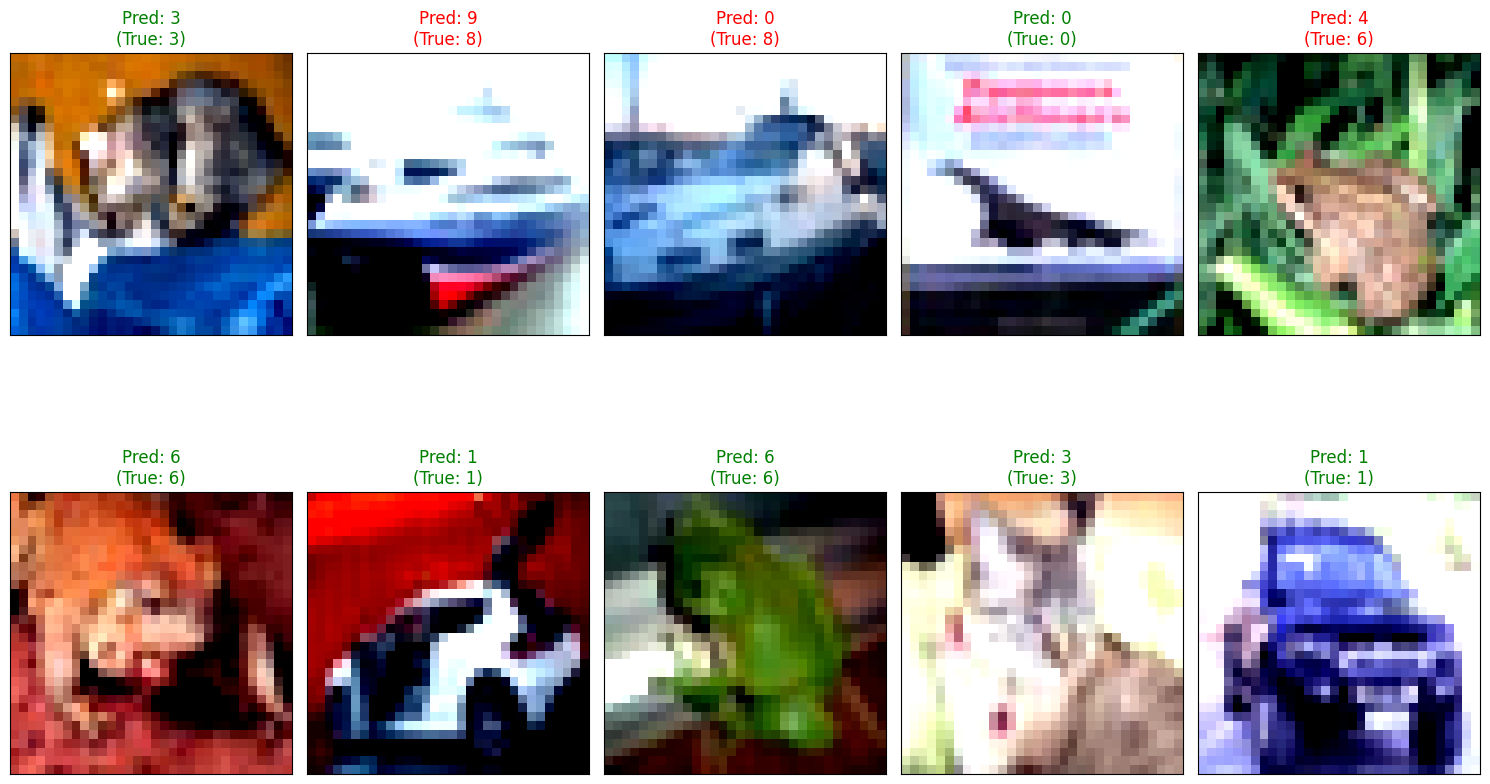

Dla najlepszego modelu:
Accuracy: 0.5323
Loss value 1.35546
Raport:
              precision    recall  f1-score   support

    airplane       0.56      0.59      0.58       973
  automobile       0.66      0.60      0.63      1010
        bird       0.43      0.34      0.38      1006
         cat       0.39      0.33      0.36       967
        deer       0.48      0.42      0.45       963
         dog       0.48      0.43      0.45      1024
        frog       0.50      0.65      0.57      1025
       horse       0.59      0.64      0.61      1035
        ship       0.64      0.69      0.66       998
       truck       0.55      0.60      0.58       999

    accuracy                           0.53     10000
   macro avg       0.53      0.53      0.53     10000
weighted avg       0.53      0.53      0.53     10000



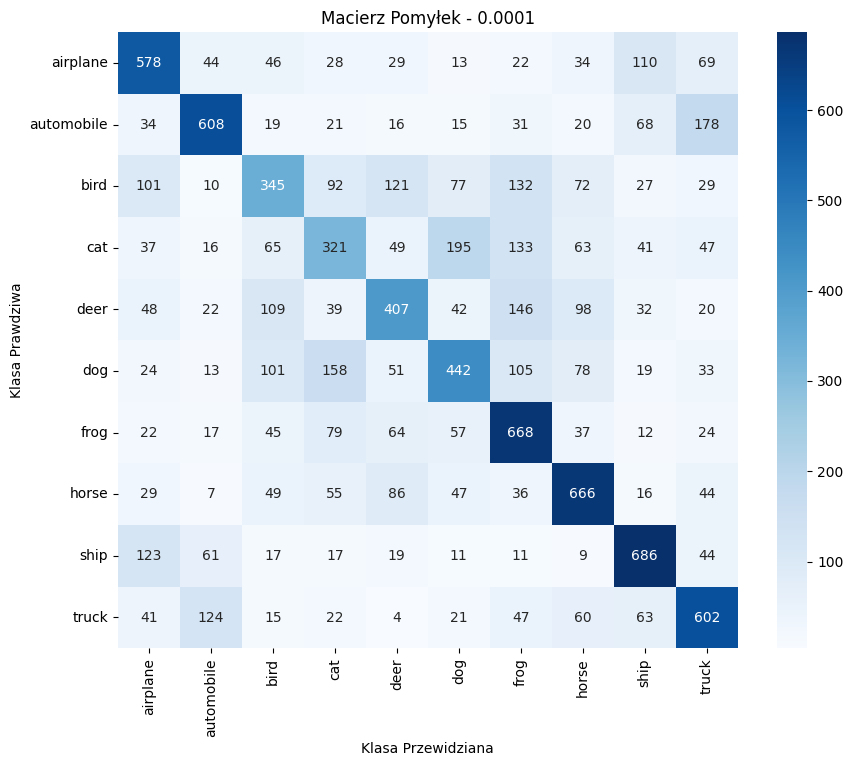

-> Trenowanie z learning ratem: 0.001
Błąd walidacji wzrósł (1.4036 -> 1.4258). Spadek z rzędu: 1/3
Błąd walidacji wzrósł (1.4258 -> 1.4400). Spadek z rzędu: 2/3
Błąd walidacji wzrósł (1.4264 -> 1.4531). Spadek z rzędu: 1/3
Błąd walidacji wzrósł (1.4531 -> 1.4904). Spadek z rzędu: 2/3
Błąd walidacji wzrósł (1.4776 -> 1.5489). Spadek z rzędu: 1/3
Błąd walidacji wzrósł (1.5489 -> 1.6243). Spadek z rzędu: 2/3
Błąd walidacji wzrósł (1.6243 -> 1.6968). Spadek z rzędu: 3/3
[Early Stopping] Epoka 13: Val Loss: 1.6968


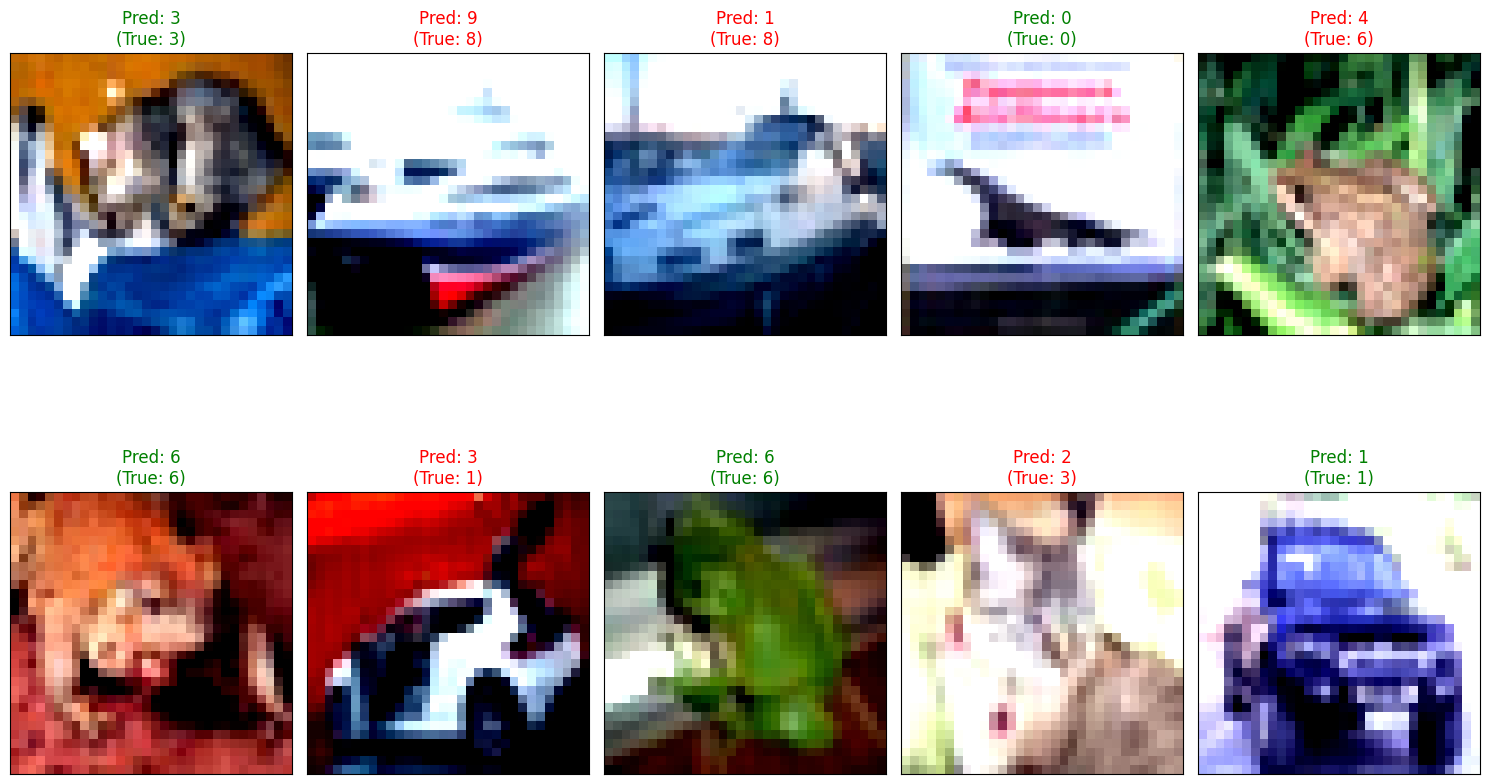

Dla najlepszego modelu:
Accuracy: 0.5134
Loss value 1.40363
Raport:
              precision    recall  f1-score   support

    airplane       0.56      0.57      0.56       973
  automobile       0.57      0.70      0.63      1010
        bird       0.48      0.27      0.35      1006
         cat       0.34      0.42      0.38       967
        deer       0.43      0.40      0.42       963
         dog       0.49      0.30      0.37      1024
        frog       0.48      0.68      0.56      1025
       horse       0.55      0.59      0.57      1035
        ship       0.68      0.62      0.64       998
       truck       0.57      0.56      0.56       999

    accuracy                           0.51     10000
   macro avg       0.51      0.51      0.51     10000
weighted avg       0.52      0.51      0.51     10000



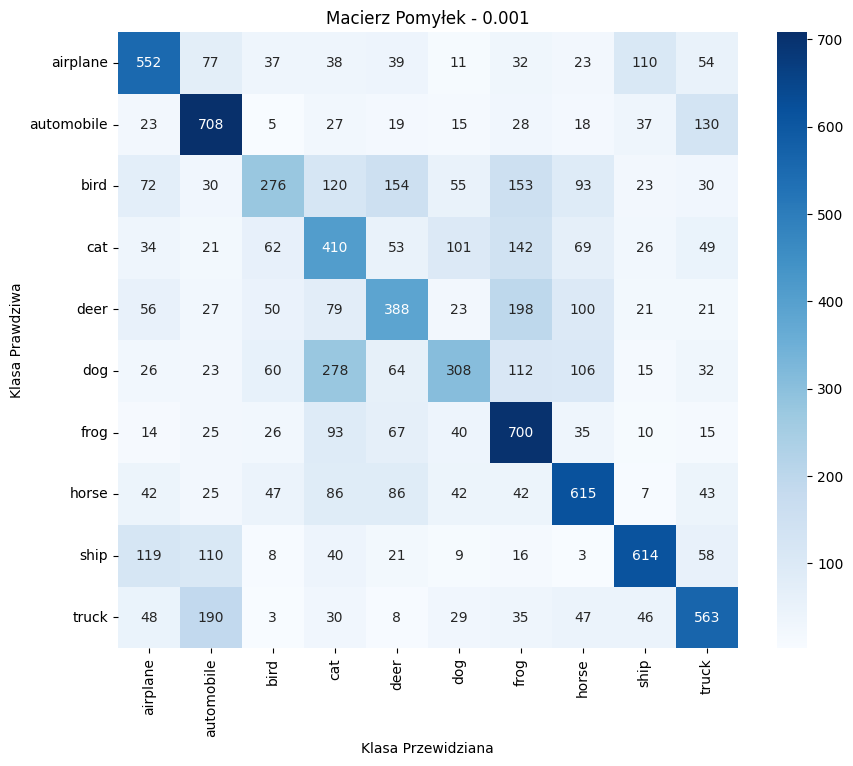

-> Trenowanie z learning ratem: 0.01
Błąd walidacji wzrósł (2.0223 -> 2.0409). Spadek z rzędu: 1/3
Błąd walidacji wzrósł (1.9885 -> 2.0113). Spadek z rzędu: 1/3
Błąd walidacji wzrósł (2.0113 -> 2.0160). Spadek z rzędu: 2/3
Błąd walidacji wzrósł (2.0095 -> 2.0333). Spadek z rzędu: 1/3
Błąd walidacji wzrósł (2.0333 -> 2.0374). Spadek z rzędu: 2/3
Błąd walidacji wzrósł (2.0174 -> 2.0271). Spadek z rzędu: 1/3
Błąd walidacji wzrósł (2.0232 -> 2.0412). Spadek z rzędu: 1/3
Błąd walidacji wzrósł (2.0412 -> 2.0639). Spadek z rzędu: 2/3
Błąd walidacji wzrósł (2.0639 -> 2.1140). Spadek z rzędu: 3/3
[Early Stopping] Epoka 15: Val Loss: 2.1140


c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

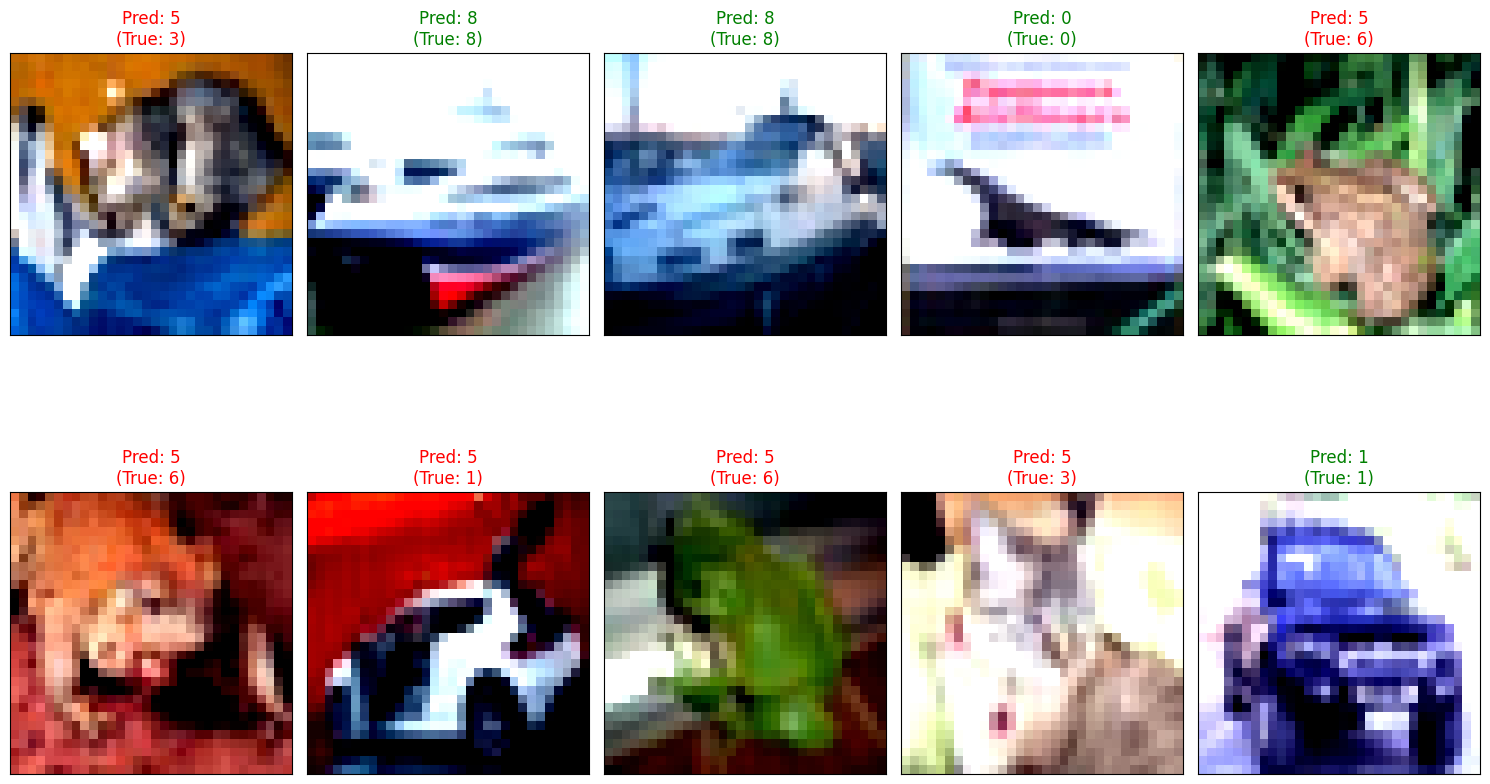

Dla najlepszego modelu:
Accuracy: 0.2336
Loss value 1.98848
Raport:
              precision    recall  f1-score   support

    airplane       0.44      0.36      0.40       973
  automobile       0.39      0.50      0.44      1010
        bird       0.11      0.02      0.04      1006
         cat       0.00      0.00      0.00       967
        deer       0.33      0.00      0.00       963
         dog       0.15      0.93      0.25      1024
        frog       0.00      0.00      0.00      1025
       horse       0.17      0.00      0.00      1035
        ship       0.46      0.45      0.46       998
       truck       0.29      0.06      0.10       999

    accuracy                           0.23     10000
   macro avg       0.23      0.23      0.17     10000
weighted avg       0.23      0.23      0.17     10000



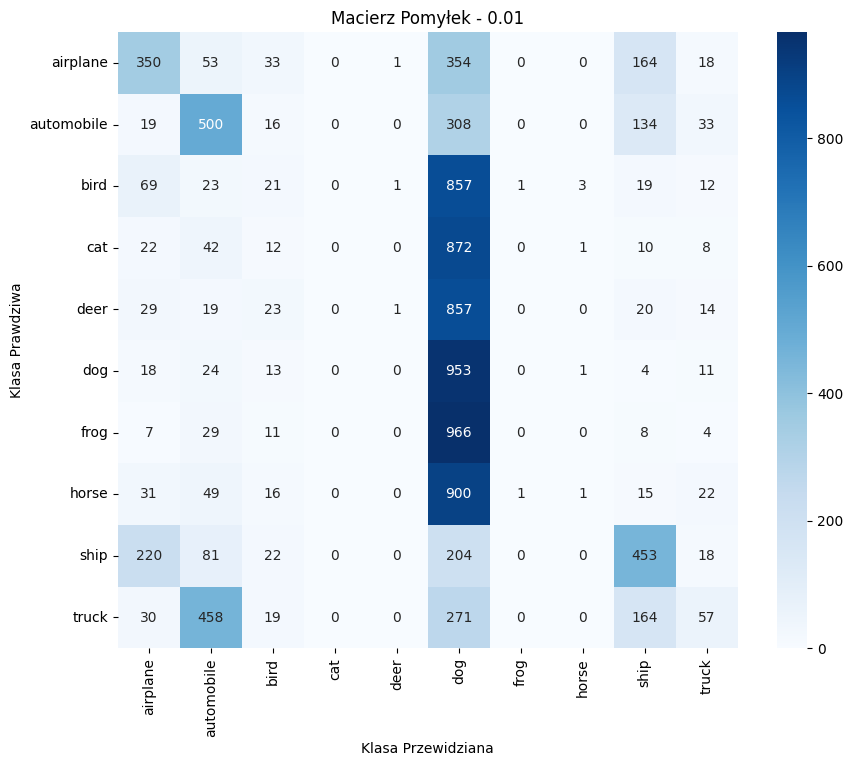

-> Trenowanie z learning ratem: 0.1
Błąd walidacji wzrósł (2.3083 -> 2.3146). Spadek z rzędu: 1/3
Błąd walidacji wzrósł (2.3068 -> 2.3135). Spadek z rzędu: 1/3
Błąd walidacji wzrósł (2.3135 -> 2.3157). Spadek z rzędu: 2/3
Błąd walidacji wzrósł (2.3149 -> 2.3169). Spadek z rzędu: 1/3
Błąd walidacji wzrósł (2.3077 -> 2.3091). Spadek z rzędu: 1/3
Błąd walidacji wzrósł (2.3091 -> 2.3167). Spadek z rzędu: 2/3
Błąd walidacji wzrósł (2.3069 -> 2.3203). Spadek z rzędu: 1/3
Błąd walidacji wzrósł (2.3083 -> 2.3184). Spadek z rzędu: 1/3
Błąd walidacji wzrósł (2.3072 -> 2.3154). Spadek z rzędu: 1/3
Błąd walidacji wzrósł (2.3154 -> 2.3205). Spadek z rzędu: 2/3
Błąd walidacji wzrósł (2.3111 -> 2.3185). Spadek z rzędu: 1/3
Błąd walidacji wzrósł (2.3161 -> 2.3243). Spadek z rzędu: 1/3
Błąd walidacji wzrósł (2.3155 -> 2.3198). Spadek z rzędu: 1/3
Błąd walidacji wzrósł (2.3084 -> 2.3102). Spadek z rzędu: 1/3
Błąd walidacji wzrósł (2.3102 -> 2.3162). Spadek z rzędu: 2/3


c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

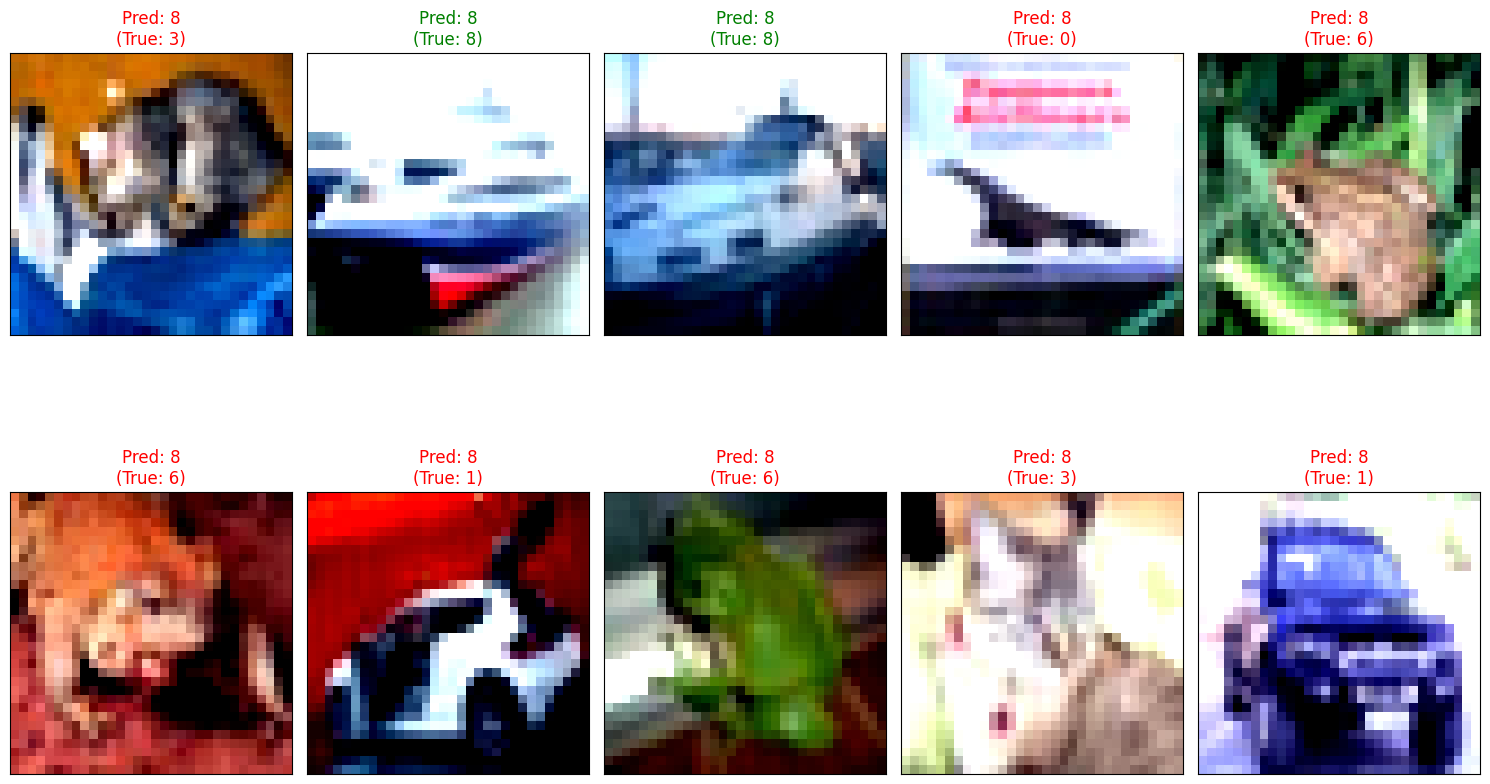

Dla najlepszego modelu:
Accuracy: 0.0998
Loss value 2.30680
Raport:
              precision    recall  f1-score   support

    airplane       0.00      0.00      0.00       973
  automobile       0.00      0.00      0.00      1010
        bird       0.00      0.00      0.00      1006
         cat       0.00      0.00      0.00       967
        deer       0.00      0.00      0.00       963
         dog       0.00      0.00      0.00      1024
        frog       0.00      0.00      0.00      1025
       horse       0.00      0.00      0.00      1035
        ship       0.10      1.00      0.18       998
       truck       0.00      0.00      0.00       999

    accuracy                           0.10     10000
   macro avg       0.01      0.10      0.02     10000
weighted avg       0.01      0.10      0.02     10000



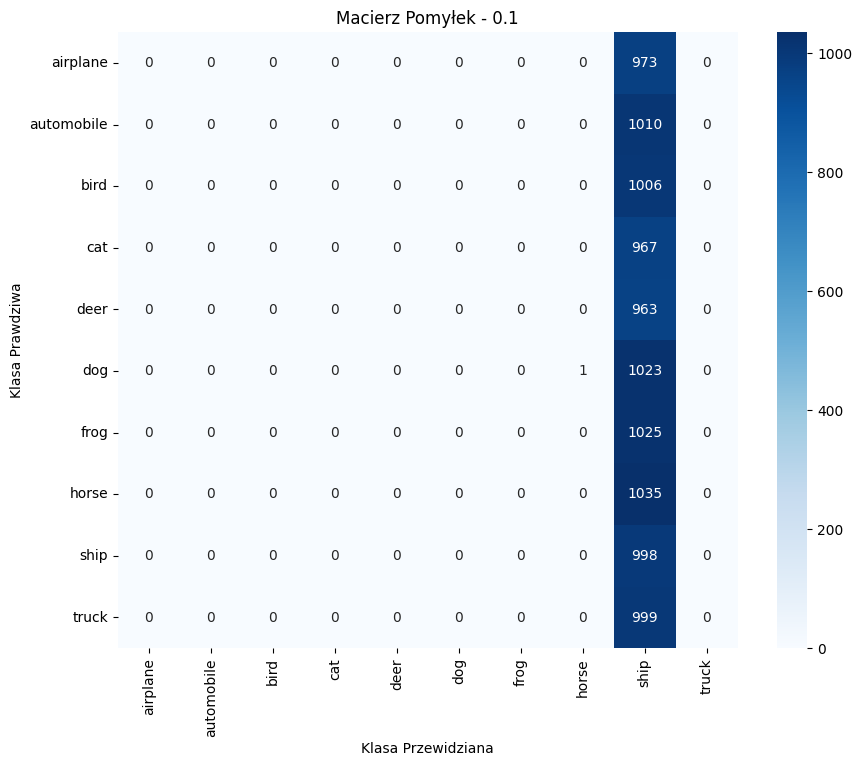

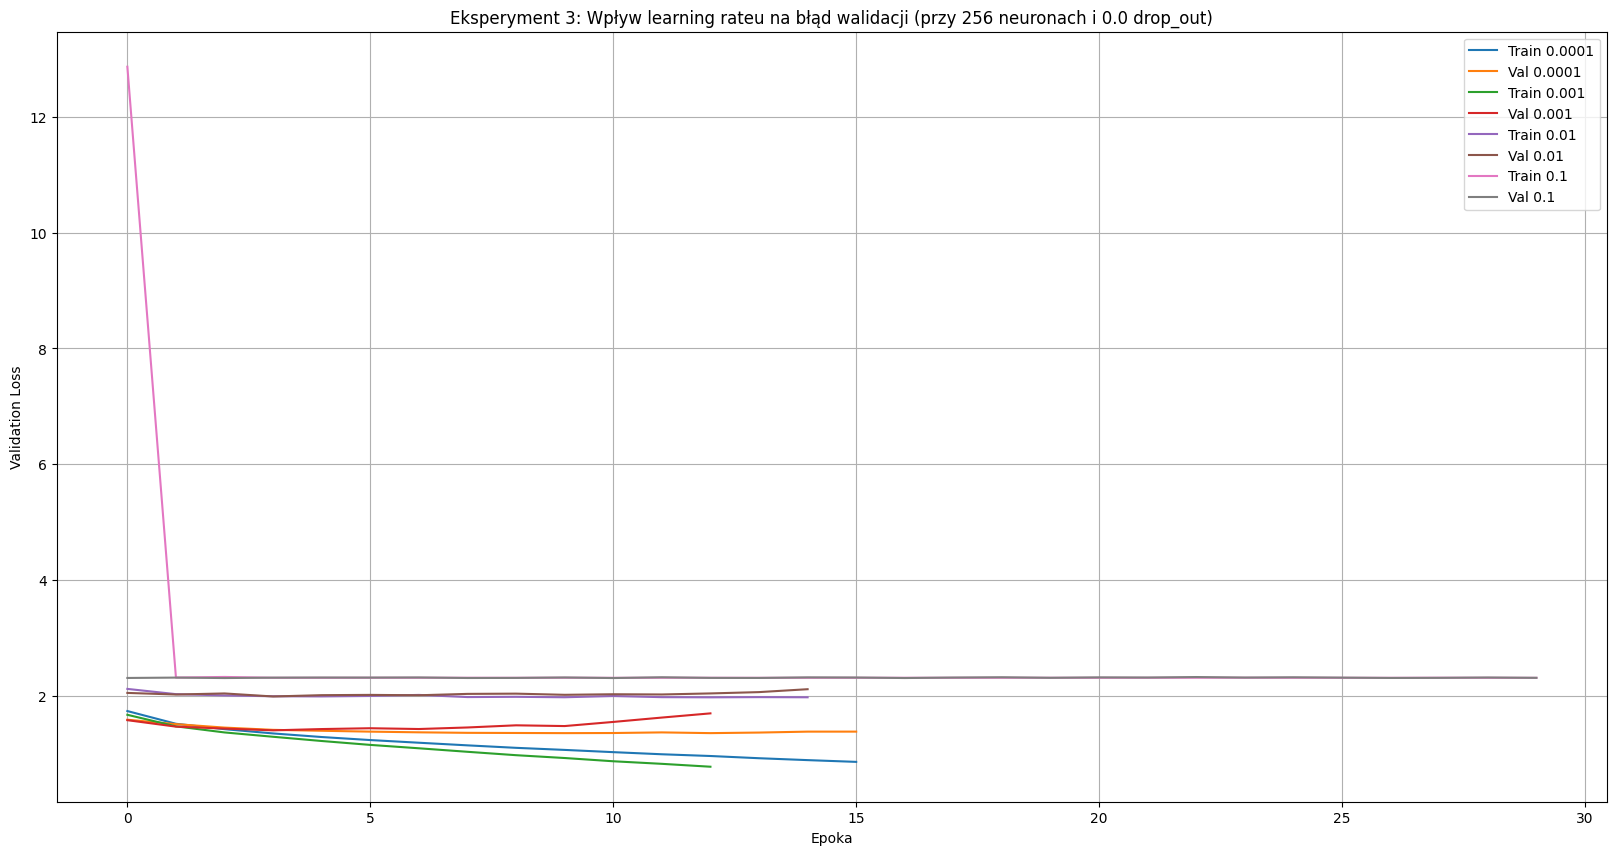

In [16]:
learning_rates_to_test = [0.0001, 0.001, 0.01, 0.1]
results_dropout = {}

print("\nROZPOCZĘCIE EKSPERYMENTU 3: Learning rate")
for learn_rate in learning_rates_to_test:
    print(f"-> Trenowanie z learning ratem: {learn_rate}")
    # Używamy 256 neuronów jako stałej bazy
    history, acc, cm, report, best_v_loss = run_experiment(hidden_neurons=256, dropout_p=0.0, learning_rate=learn_rate, train_loader=train_loader, val_loader=val_loader)
    results_dropout[learn_rate] = history
    wykresy(acc, cm, report, learn_rate, best_v_loss)

# Rysowanie wykresu
plt.figure(figsize=(20, 10))
for learn_rate, history in results_dropout.items():
    plt.plot(history['train'], label=f'Train {learn_rate}')
    plt.plot(history['val'], label=f'Val {learn_rate}')

plt.title('Eksperyment 3: Wpływ learning rateu na błąd walidacji (przy 256 neuronach i 0.0 drop_out)')
plt.xlabel('Epoka')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(True)

##### Eksperyment potwierdził, że Learning Rate (LR) jest kluczowym parametrem determinującym zbieżność modelu. Skrajnie wysoka wartość (0.1, linia różowa) doprowadziła do natychmiastowej destabilizacji – błąd rzędu 13 w pierwszej epoce sugeruje zjawisko "eksplodujących gradientów", po których model utknął w martwym punkcie (Loss $\approx$ 2.3).Wartość 0.01 (linia fioletowa/brązowa) również okazała się zbyt wysoka, skutkując brakiem postępów w nauce. Za najlepszy parametr uznano 0.0001 (linia niebieska/pomarańczowa), który zapewnił najstabilniejszą zbieżność i pozwolił osiągnąć najwyższą dokładność na poziomie Acc = 0.53. Choć wartość 0.001 (linia zielona/czerwona) szybciej minimalizowała błąd, po 10. epoce wykazała oznaki overfittingu (wzrost błędu walidacyjnego). Wynika z tego, że mniejszy krok uczenia sprzyja precyzyjniejszej generalizacji w architekturze MLP dla zbioru CIFAR-10.

## Eksperyment 4 z wartością batch size


ROZPOCZĘCIE EKSPERYMENTU 4: Batch size
-> Trenowanie z batch sizem: 16
Błąd walidacji wzrósł (1.4697 -> 1.4720). Spadek z rzędu: 1/3
Błąd walidacji wzrósł (1.4720 -> 1.4835). Spadek z rzędu: 2/3
Błąd walidacji wzrósł (1.4835 -> 1.5023). Spadek z rzędu: 3/3
[Early Stopping] Epoka 7: Val Loss: 1.5023


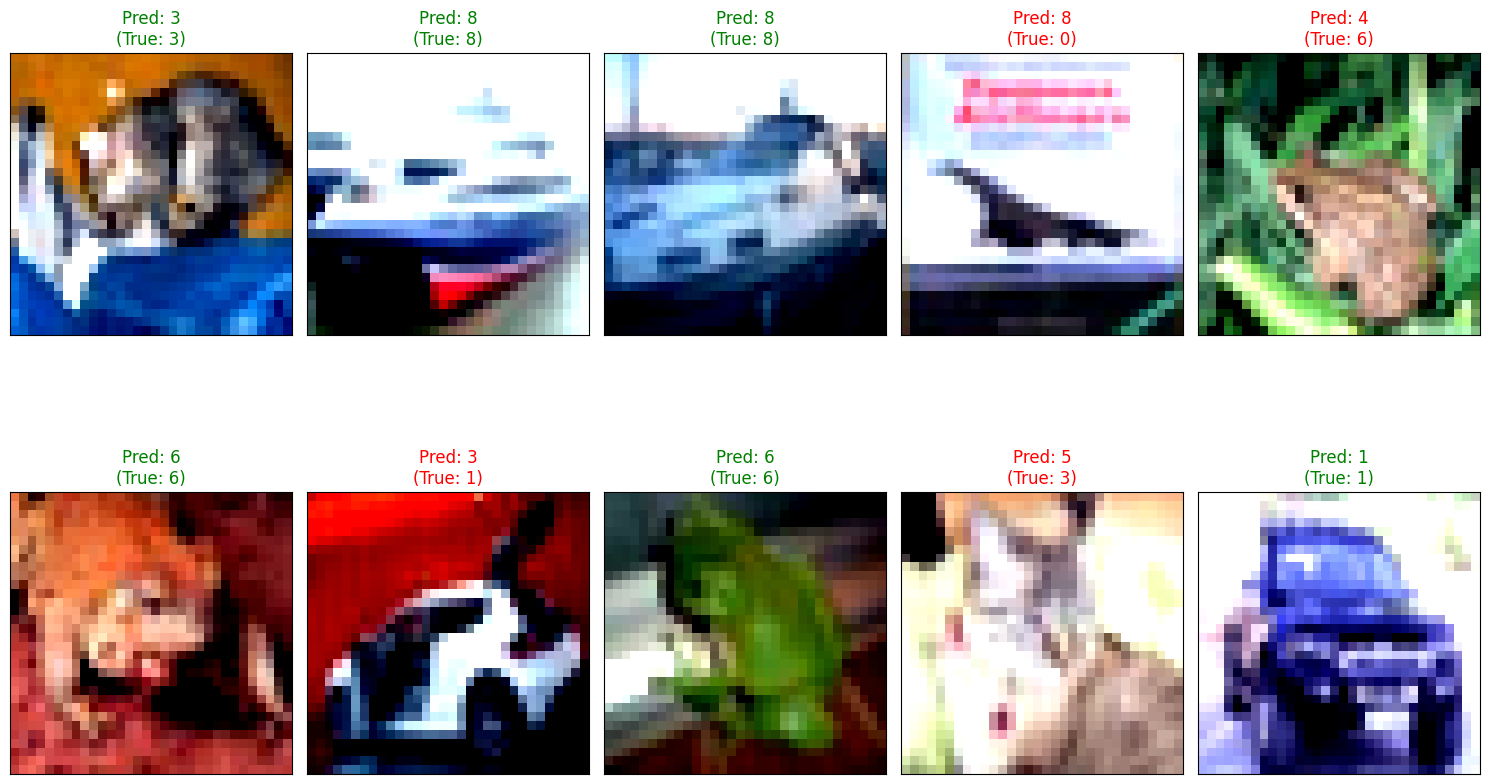

Dla najlepszego modelu:
Accuracy: 0.4829
Loss value 1.46971
Raport:
              precision    recall  f1-score   support

    airplane       0.58      0.51      0.54       973
  automobile       0.60      0.57      0.59      1010
        bird       0.40      0.24      0.30      1006
         cat       0.29      0.54      0.38       967
        deer       0.37      0.51      0.43       963
         dog       0.42      0.22      0.29      1024
        frog       0.57      0.49      0.53      1025
       horse       0.63      0.48      0.55      1035
        ship       0.60      0.66      0.63       998
       truck       0.54      0.60      0.57       999

    accuracy                           0.48     10000
   macro avg       0.50      0.48      0.48     10000
weighted avg       0.50      0.48      0.48     10000



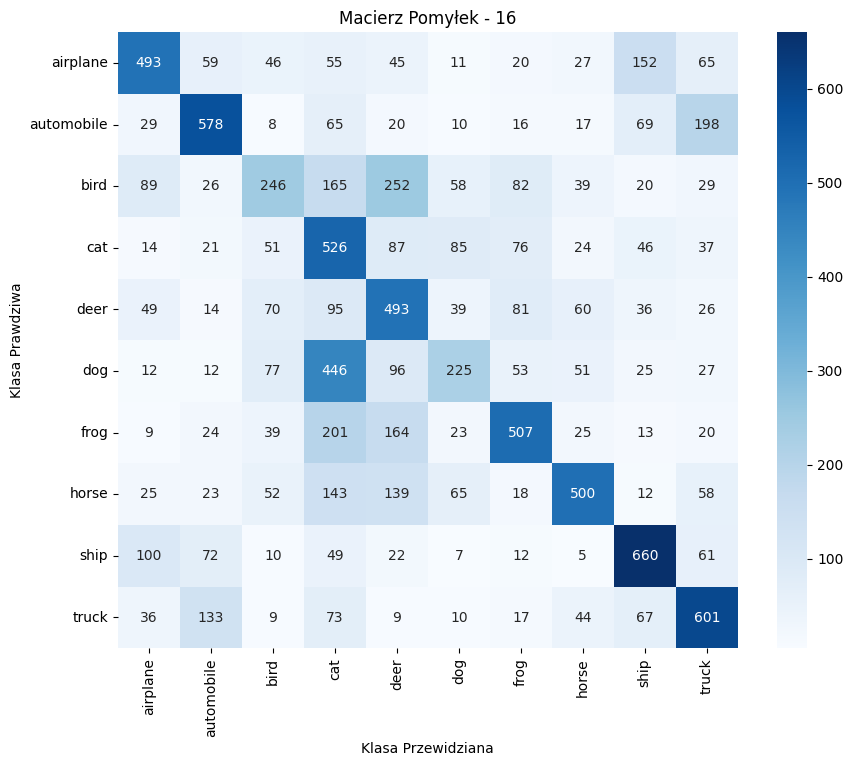

-> Trenowanie z batch sizem: 32
Błąd walidacji wzrósł (1.4546 -> 1.4648). Spadek z rzędu: 1/3
Błąd walidacji wzrósł (1.4648 -> 1.4667). Spadek z rzędu: 2/3
Błąd walidacji wzrósł (1.4377 -> 1.4615). Spadek z rzędu: 1/3
Błąd walidacji wzrósł (1.4615 -> 1.4698). Spadek z rzędu: 2/3
Błąd walidacji wzrósł (1.4698 -> 1.5237). Spadek z rzędu: 3/3
[Early Stopping] Epoka 10: Val Loss: 1.5237


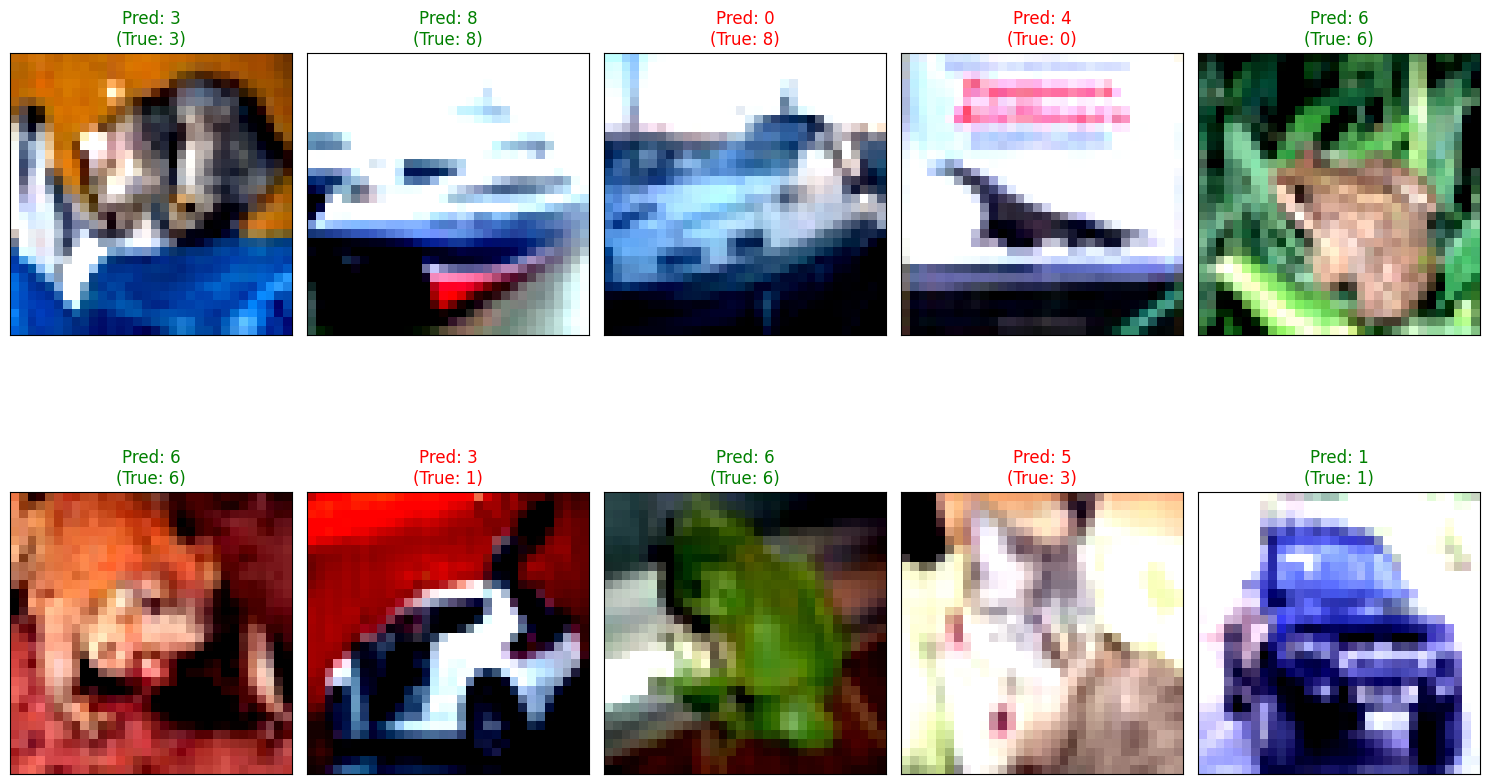

Dla najlepszego modelu:
Accuracy: 0.5047
Loss value 1.43771
Raport:
              precision    recall  f1-score   support

    airplane       0.56      0.55      0.56       973
  automobile       0.59      0.62      0.61      1010
        bird       0.37      0.41      0.39      1006
         cat       0.31      0.33      0.32       967
        deer       0.45      0.42      0.43       963
         dog       0.43      0.42      0.42      1024
        frog       0.52      0.58      0.55      1025
       horse       0.64      0.54      0.59      1035
        ship       0.66      0.61      0.63       998
       truck       0.55      0.57      0.56       999

    accuracy                           0.50     10000
   macro avg       0.51      0.50      0.51     10000
weighted avg       0.51      0.50      0.51     10000



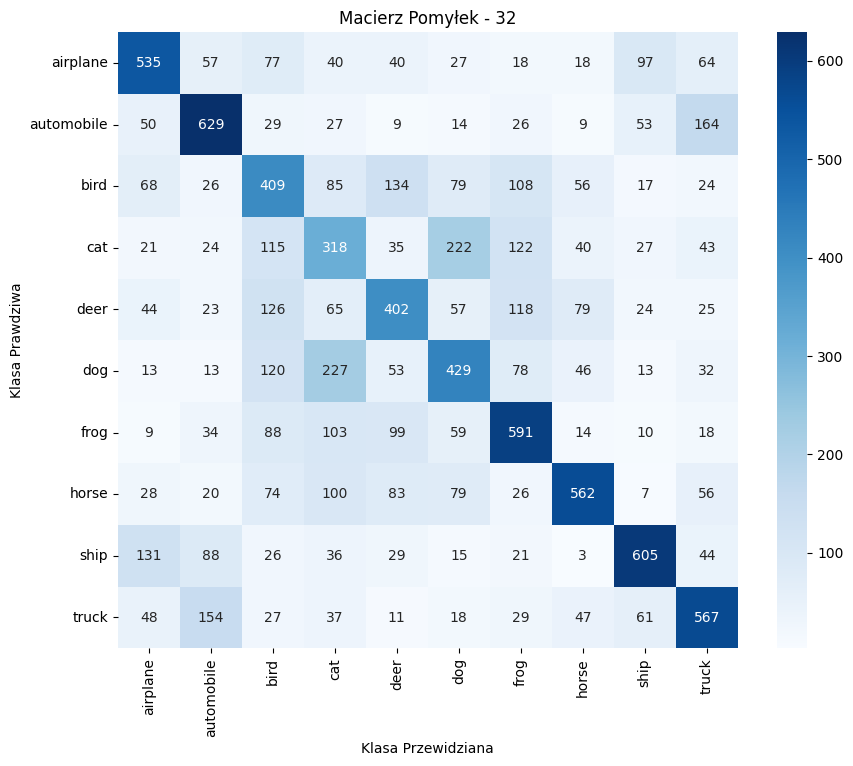

-> Trenowanie z batch sizem: 64
Błąd walidacji wzrósł (1.4155 -> 1.4556). Spadek z rzędu: 1/3
Błąd walidacji wzrósł (1.4456 -> 1.4778). Spadek z rzędu: 1/3
Błąd walidacji wzrósł (1.4778 -> 1.4943). Spadek z rzędu: 2/3
Błąd walidacji wzrósł (1.4943 -> 1.4961). Spadek z rzędu: 3/3
[Early Stopping] Epoka 9: Val Loss: 1.4961


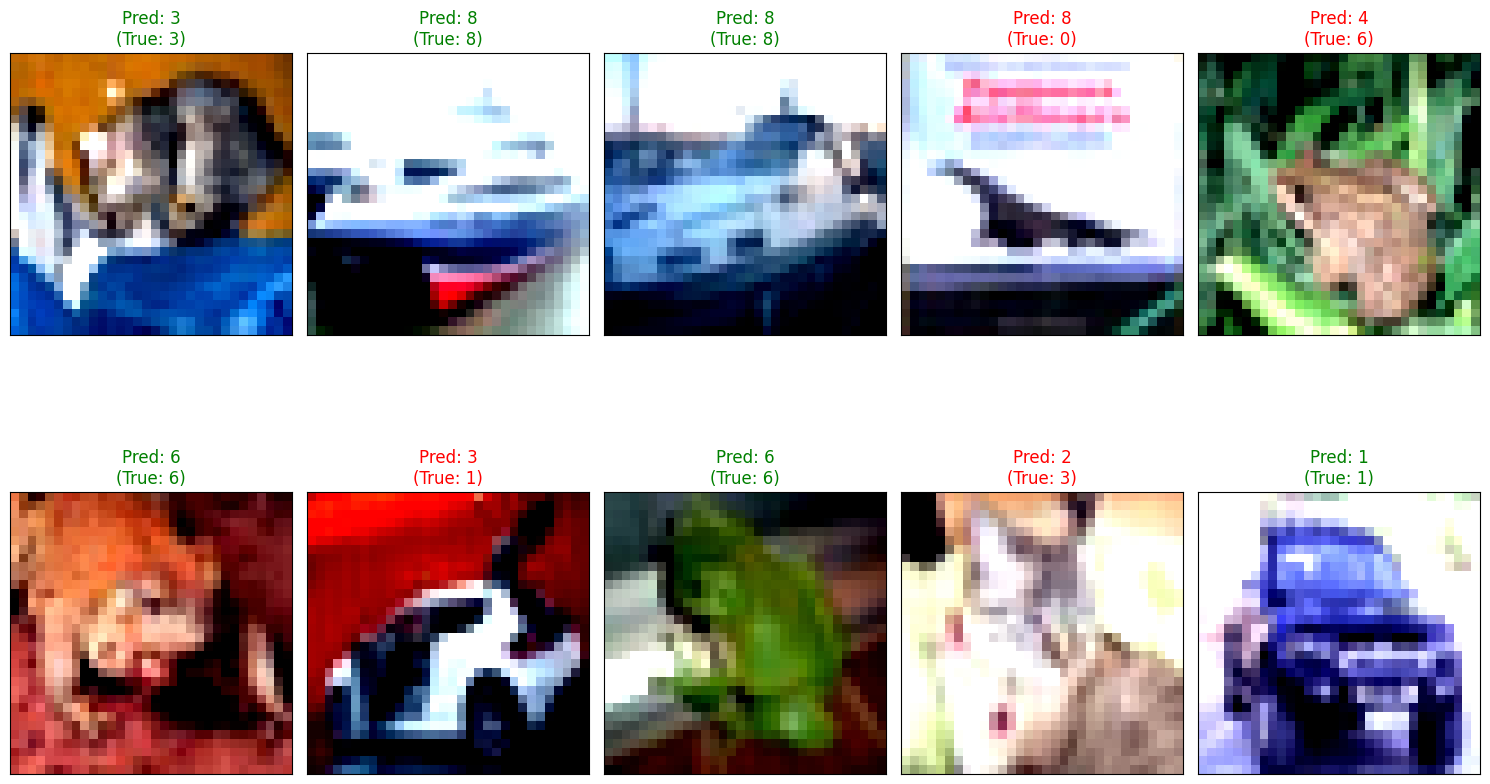

Dla najlepszego modelu:
Accuracy: 0.509
Loss value 1.41545
Raport:
              precision    recall  f1-score   support

    airplane       0.55      0.56      0.56       973
  automobile       0.66      0.59      0.62      1010
        bird       0.41      0.32      0.36      1006
         cat       0.35      0.36      0.35       967
        deer       0.49      0.36      0.41       963
         dog       0.48      0.31      0.38      1024
        frog       0.46      0.68      0.55      1025
       horse       0.54      0.62      0.58      1035
        ship       0.61      0.68      0.64       998
       truck       0.53      0.59      0.56       999

    accuracy                           0.51     10000
   macro avg       0.51      0.51      0.50     10000
weighted avg       0.51      0.51      0.50     10000



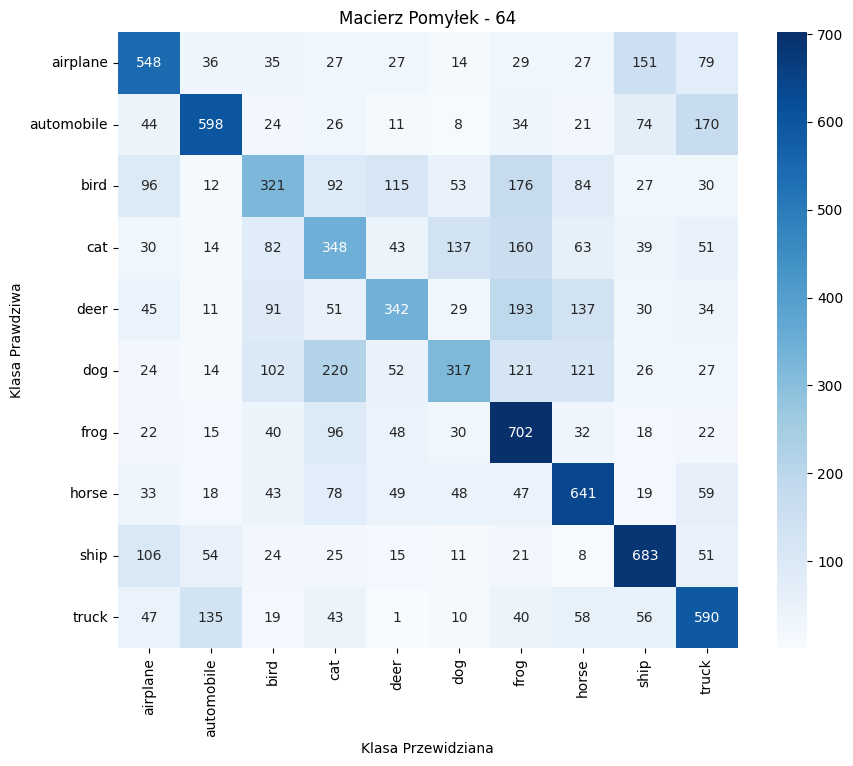

-> Trenowanie z batch sizem: 128
Błąd walidacji wzrósł (1.4213 -> 1.4626). Spadek z rzędu: 1/3
Błąd walidacji wzrósł (1.4138 -> 1.4463). Spadek z rzędu: 1/3
Błąd walidacji wzrósł (1.4463 -> 1.4899). Spadek z rzędu: 2/3
Błąd walidacji wzrósł (1.4899 -> 1.5020). Spadek z rzędu: 3/3
[Early Stopping] Epoka 10: Val Loss: 1.5020


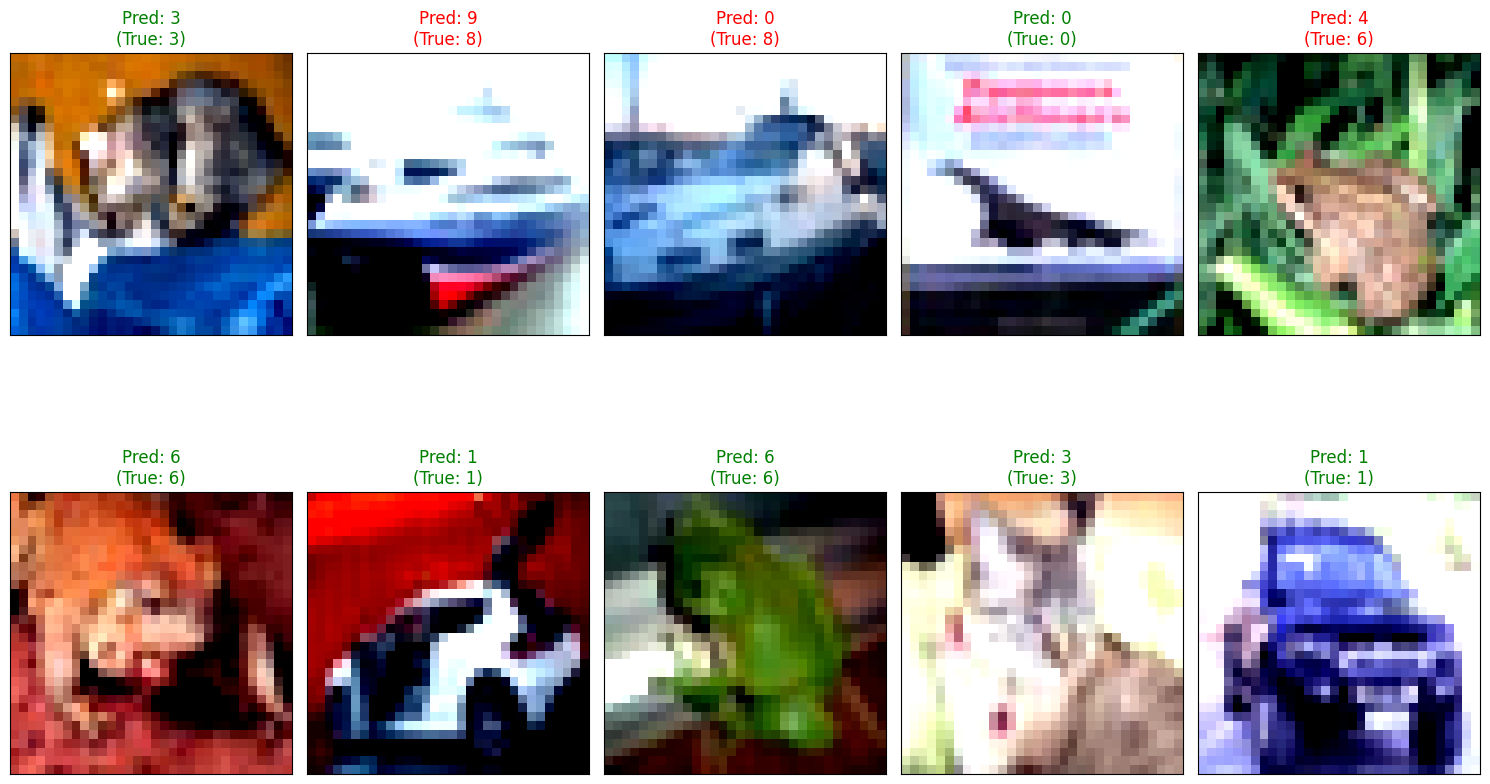

Dla najlepszego modelu:
Accuracy: 0.5243
Loss value 1.41384
Raport:
              precision    recall  f1-score   support

    airplane       0.55      0.58      0.57       973
  automobile       0.66      0.64      0.65      1010
        bird       0.44      0.35      0.39      1006
         cat       0.34      0.39      0.37       967
        deer       0.44      0.45      0.44       963
         dog       0.43      0.39      0.41      1024
        frog       0.55      0.62      0.58      1025
       horse       0.62      0.59      0.61      1035
        ship       0.62      0.66      0.64       998
       truck       0.58      0.55      0.57       999

    accuracy                           0.52     10000
   macro avg       0.52      0.52      0.52     10000
weighted avg       0.52      0.52      0.52     10000



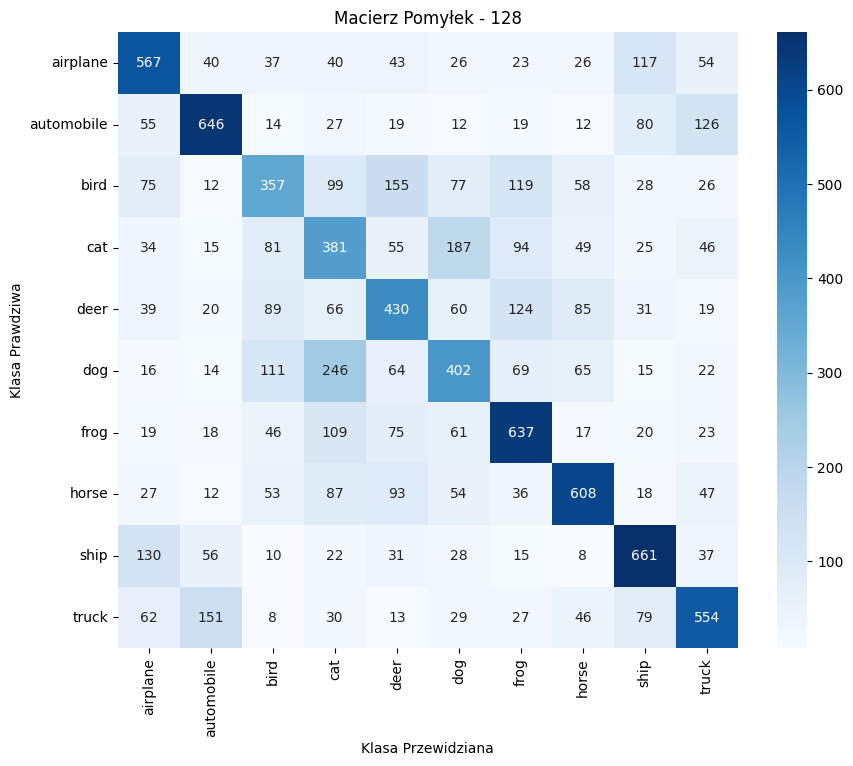

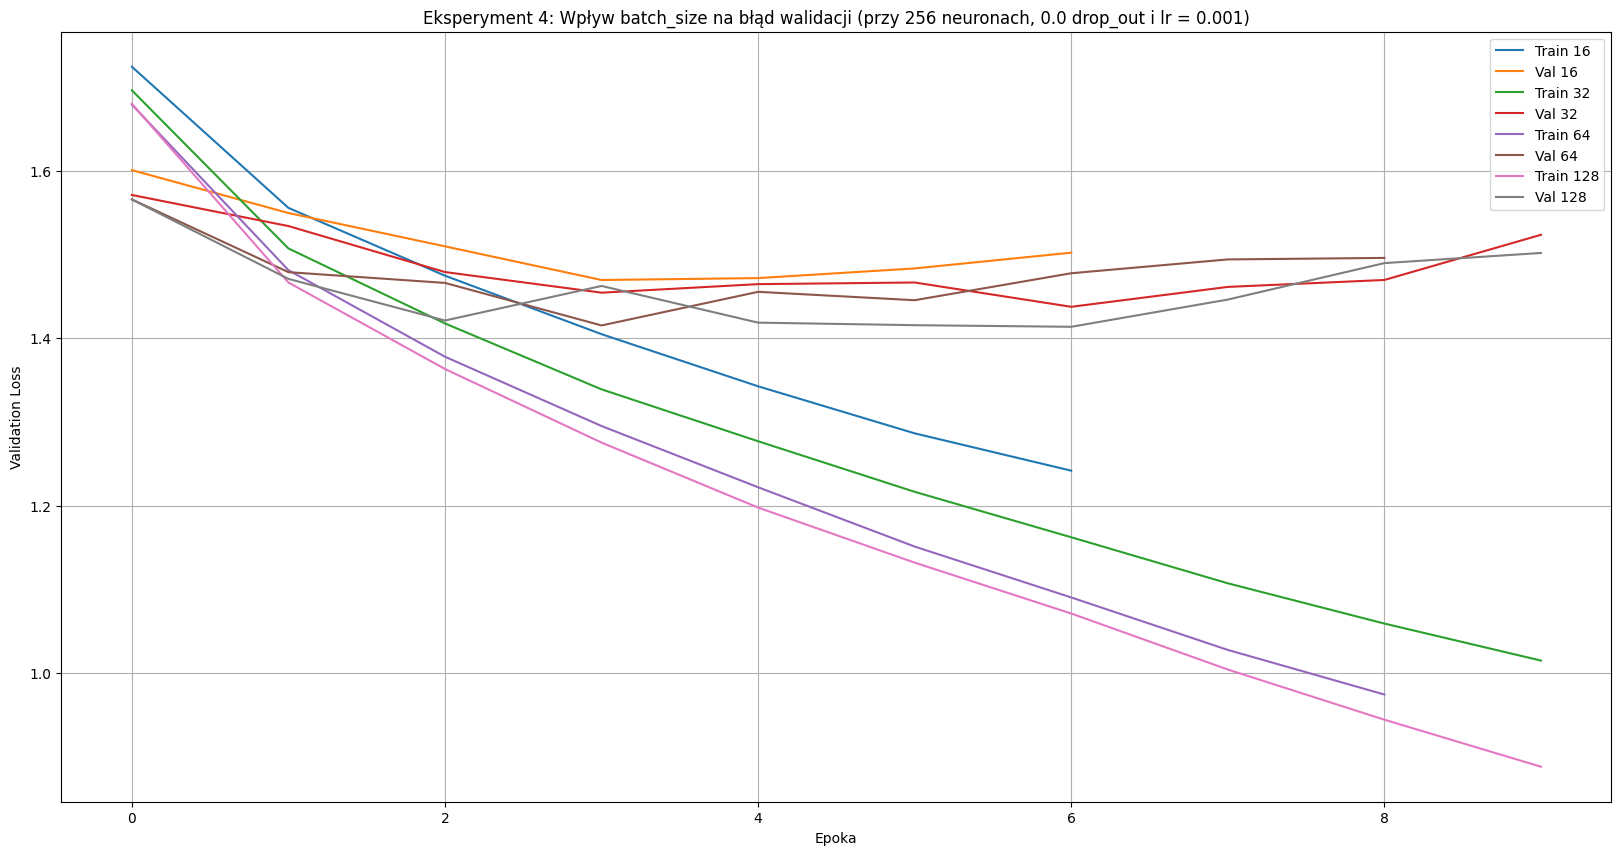

In [17]:
batch_sizes = [16, 32, 64, 128]
results_batch = {}
print("\nROZPOCZĘCIE EKSPERYMENTU 4: Batch size")
for bat_size in batch_sizes:

    train_loader = DataLoader(train_dataset, batch_size=bat_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=bat_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=bat_size, shuffle=False)

    print(f"-> Trenowanie z batch sizem: {bat_size}")
    # Używamy 256 neuronów jako stałej bazy
    history, acc, cm, report, best_v_loss = run_experiment(hidden_neurons=256, dropout_p=0.0, learning_rate=0.001, train_loader=train_loader, val_loader=val_loader)
    results_batch[bat_size] = history
    wykresy(acc, cm, report, bat_size, best_v_loss)

    # Rysowanie wykresu
plt.figure(figsize=(20, 10))
for bat_size, history in results_batch.items():
    plt.plot(history['train'], label=f'Train {bat_size}')
    plt.plot(history['val'], label=f'Val {bat_size}')
plt.title('Eksperyment 4: Wpływ batch_size na błąd walidacji (przy 256 neuronach, 0.0 drop_out i lr = 0.001)')
plt.xlabel('Epoka')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(True)
    

##### Eksperyment wykazał, że rozmiar partii determinuje balans między szybkością adaptacji a stabilnością modelu. Mniejsze wartości (16 i 32) skutkują gwałtownym spadkiem błędu w pierwszych epokach, ale wywołują najszybszy overfitting – błąd walidacyjny (linie pomarańczowa i czerwona) rośnie już po 3. epoce.

##### W przeprowadzonym eksperymencie większy rozmiar partii (Batch Size 128) zadziałał stabilizująco na proces uczenia. Dzięki redukcji szumu w estymacji gradientu, model uniknął gwałtownego przeuczenia, które było widoczne przy mniejszych paczkach (16, 32). Pozwoliło to na dłuższą i bardziej zrównoważoną optymalizację, co przełożyło się na najwyższy wynik dokładności (52%). Sugeruje to, że dla prostej architektury MLP na złożonym zbiorze CIFAR-10, silniejsze uśrednianie sygnału błędu pomaga w ekstrakcji bardziej uniwersalnych cech.

## Podsumowanie

### Przeprowadzone badania wykazały, że skuteczność prostej sieci neuronowej typu MLP w zadaniu klasyfikacji obrazów CIFAR-10 jest silnie uzależniona od precyzyjnego doboru hiperparametrów oraz zastosowania technik regularyzacji.

##### Pojemność modelu: Zwiększanie liczby neuronów (powyżej 128) drastycznie przyspiesza proces overfittingu. Modele o dużej szerokości (512 neuronów) zbyt szybko dopasowują się do danych treningowych, tracąc zdolność generalizacji już po kilku epokach. Optymalną stabilność przy zachowaniu akceptowalnej precyzji wykazały konfiguracje oparte na 128 i 256 neuronach.

##### Regularyzacja: Mechanizm Dropout okazał się kluczowym elementem stabilizującym naukę. Wartość 0.3 pozwoliła na uzyskanie najlepszego balansu – skutecznie wyhamowała wzrost błędu walidacyjnego, zmuszając sieć do ekstrakcji istotnych cech wizualnych zamiast zapamiętywania szumu.

##### Dynamika uczenia: Dobór współczynnika uczenia (Learning Rate) ma charakter krytyczny. Zbyt wysokie wartości (0.1, 0.01) prowadzą do natychmiastowej destabilizacji gradientów, podczas gdy najniższy badany parametr (0.0001) zapewnił najwyższą precyzję (Acc = 53%) i najstabilniejszą zbieżność w długim terminie.

##### Rozmiar partii: Większy rozmiar partii (Batch Size 128) zadziałał jako dodatkowa forma regularyzacji. Dzięki redukcji szumu w estymacji gradientu, model uniknął gwałtownych skoków błędu widocznych przy małych paczkach (16, 32), co przełożyło się na wynik Acc = 52%.

### Wnioski końcowe: 
##### Najlepsze wyniki osiągnięto stosując strategię „powolnej i stabilnej” nauki: mniejszy krok uczenia, większy rozmiar partii lub umiarkowany Dropout. Każdy z tych elementów niezależnie przyczynił się do opóźnienia zjawiska overfittingu i lepszej generalizacji modelu. Niemniej jednak, osiągnięte wyniki w okolicach 53% dokładności wskazują na strukturalne ograniczenia architektury MLP. Brak warstw splotowych (CNN), które natywnie wykorzystują strukturę 2D obrazu, stanowi główny "szklany sufit", którego nie da się przebić samą manipulacją hiperparametrami warstw w pełni połączonych.